# Skimlit Project 
* The project we are going to do in this project is NLP  
* In this project we are going to implement [ANN paper](https://arxiv.org/pdf/1612.05251) from the data of [skimlit paper](https://arxiv.org/abs/1710.06071)


**Main motto of improving mahine learning skills**
- Find a paper
- Implement it
- Keep doing until you have skills


## Importing the necessary libraries

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import os

2025-08-23 06:07:25.802398: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1755929246.128690      73 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1755929246.225986      73 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


## Getting the Data
we get the data for this machine learning project from https://github.com/Franck-Dernoncourt/pubmed-rct

In [ ]:
!git clone https://github.com/Franck-Dernoncourt/pubmed-rct
!ls pubmed-rct

Cloning into 'pubmed-rct'...
remote: Enumerating objects: 39, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 39 (delta 8), reused 5 (delta 5), pack-reused 25 (from 1)
Receiving objects: 100% (39/39), 177.08 MiB | 52.21 MiB/s, done.
Resolving deltas: 100% (15/15), done.
PubMed_200k_RCT
PubMed_200k_RCT_numbers_replaced_with_at_sign
PubMed_20k_RCT
PubMed_20k_RCT_numbers_replaced_with_at_sign
README.md


In [ ]:
#checking the files in 20K deataset
!ls pubmed-rct/PubMed_20k_RCT_numbers_replaced_with_at_sign

dev.txt  test.txt  train.txt


In [ ]:
data_dir="/kaggle/working/pubmed-rct/PubMed_20k_RCT_numbers_replaced_with_at_sign/"
# data_dir="/content/pubmed-rct/PubMed_20k_RCT_numbers_replaced_with_at_sign/"

In [ ]:
filenames=[data_dir+filename for filename in os.listdir(data_dir)]
filenames

['/kaggle/working/pubmed-rct/PubMed_20k_RCT_numbers_replaced_with_at_sign/train.txt',
 '/kaggle/working/pubmed-rct/PubMed_20k_RCT_numbers_replaced_with_at_sign/dev.txt',
 '/kaggle/working/pubmed-rct/PubMed_20k_RCT_numbers_replaced_with_at_sign/test.txt']

## Preprocessing Data
Once we get the data we have to **become one with data**

In [ ]:
def get_lines(filename):
    """
    Reads filename (a text file) and returns the lines of text as a list.

    Args:
        filename: a string containing the target filepath to read.

    Returns:
        A list of strings with one string per line from the target filename.
        For example:
        ["this is the first line of filename",
        "this is the second line of filename",
        "..."]
    """
    with open(filename,"r") as f:
        return f.readlines()

In [ ]:
# Let's read in the training lines
train_lines = get_lines(data_dir+"train.txt") # read the lines with the training file
print(f"No of lines in training set:{len(train_lines)}")
(train_lines[:10])

No of lines in training set:210040


['###24293578\n',
 'OBJECTIVE\tTo investigate the efficacy of @ weeks of daily low-dose oral prednisolone in improving pain , mobility , and systemic low-grade inflammation in the short term and whether the effect would be sustained at @ weeks in older adults with moderate to severe knee osteoarthritis ( OA ) .\n',
 'METHODS\tA total of @ patients with primary knee OA were randomized @:@ ; @ received @ mg/day of prednisolone and @ received placebo for @ weeks .\n',
 'METHODS\tOutcome measures included pain reduction and improvement in function scores and systemic inflammation markers .\n',
 'METHODS\tPain was assessed using the visual analog pain scale ( @-@ mm ) .\n',
 'METHODS\tSecondary outcome measures included the Western Ontario and McMaster Universities Osteoarthritis Index scores , patient global assessment ( PGA ) of the severity of knee OA , and @-min walk distance ( @MWD ) .\n',
 'METHODS\tSerum levels of interleukin @ ( IL-@ ) , IL-@ , tumor necrosis factor ( TNF ) - , and 

Before preprocessing we have to understand how the data after preprocessing should look

```python
[
    {
        'line_number':0, #line number in a particular case
        'target':'background',
        'text':'some text that is training input',
        'total lines':11  #total no of sample from that medical_case starting from 0
    }
]
```

In [ ]:
def extract_lines_and_structure(filename):
    """
        takes in a `filename` and returns a list of dictionaries, one per line in the file.
        the structure of each dictionary is as follows:
        ```python
        {
            'line_number':0,
            'target':'background',
            'text':'some text that is training input',
            'total lines':11
        }```
    """
    lines=get_lines(filename)
    medical_case=""
    extracted_structured_data=[]
    for line in lines:
        #starting the recording of medical case from scratch
        if line.startswith("###"):
            medical_case=""#starting new case
        #appending the samples got from medical case
        elif line.isspace():
            samples=medical_case.splitlines()
            for i,sample in enumerate(samples):
                split_sample=sample.split("\t")
                extracted_structured_data.append(
                    {
                        'target':split_sample[0],
                        'text':split_sample[1].lower(),
                        'line_number':i,#line number in a particular case
                        'total lines':len(samples)-1 #total no of sample from that medical_case starting from 0
                    }
                )
        # creating the medical case
        else:
            medical_case+=line
    return extracted_structured_data





In [ ]:
%%time
train_samples=extract_lines_and_structure(data_dir+"train.txt")
validation_samples=extract_lines_and_structure(data_dir+"dev.txt")
test_samples=extract_lines_and_structure(data_dir+"test.txt")
print(f"No of training samples:{len(train_samples)}")
print(f"No of validation samples:{len(validation_samples)}")
print(f"No of test samples:{len(test_samples)}")

No of training samples:180040
No of validation samples:30212
No of test samples:30135
CPU times: user 336 ms, sys: 120 ms, total: 456 ms
Wall time: 453 ms


In [ ]:
#Lets check the data we got
train_samples[:14]

[{'target': 'OBJECTIVE',
  'text': 'to investigate the efficacy of @ weeks of daily low-dose oral prednisolone in improving pain , mobility , and systemic low-grade inflammation in the short term and whether the effect would be sustained at @ weeks in older adults with moderate to severe knee osteoarthritis ( oa ) .',
  'line_number': 0,
  'total lines': 11},
 {'target': 'METHODS',
  'text': 'a total of @ patients with primary knee oa were randomized @:@ ; @ received @ mg/day of prednisolone and @ received placebo for @ weeks .',
  'line_number': 1,
  'total lines': 11},
 {'target': 'METHODS',
  'text': 'outcome measures included pain reduction and improvement in function scores and systemic inflammation markers .',
  'line_number': 2,
  'total lines': 11},
 {'target': 'METHODS',
  'text': 'pain was assessed using the visual analog pain scale ( @-@ mm ) .',
  'line_number': 3,
  'total lines': 11},
 {'target': 'METHODS',
  'text': 'secondary outcome measures included the western ontari

In [ ]:
import pandas as pd

train_df=pd.DataFrame(train_samples)
validation_df=pd.DataFrame(validation_samples)
test_df=pd.DataFrame(test_samples)
train_df.head()

,target,text,line_number,total lines
0,OBJECTIVE,to investigate the efficacy of @ weeks of dail...,0,11
1,METHODS,a total of @ patients with primary knee oa wer...,1,11
2,METHODS,outcome measures included pain reduction and i...,2,11
3,METHODS,pain was assessed using the visual analog pain...,3,11
4,METHODS,secondary outcome measures included the wester...,4,11


In [ ]:
import matplotlib.pyplot as plt

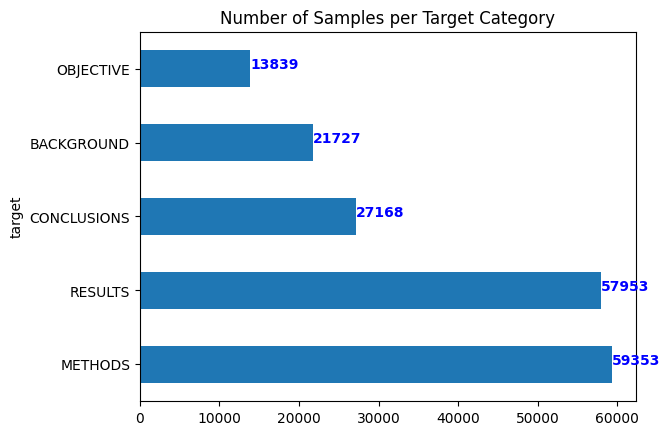

In [ ]:
ax = train_df['target'].value_counts().plot(kind='barh', title='Number of Samples per Target Category')
for i, v in enumerate(train_df['target'].value_counts()):
    ax.text(v , i , str(v), color='blue', fontweight='bold')

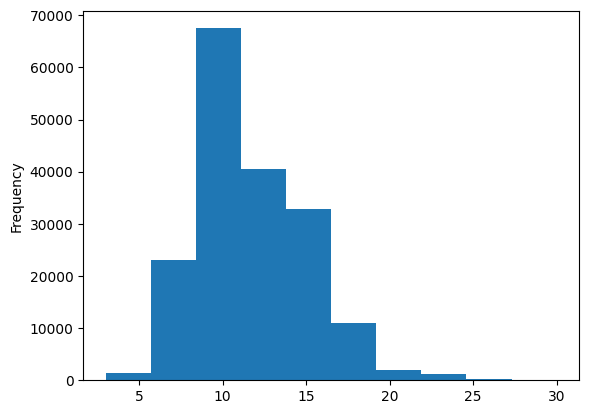

In [ ]:
train_df['total lines'].plot.hist();

#### getting data sentences

In [ ]:
train_sentences=train_df['text'].to_list()
validation_sentences=validation_df['text'].to_list()
test_sentences=test_df['text'].to_list()
print(len(train_sentences))
print(len(validation_sentences))
print(len(test_sentences))

180040
30212
30135


**preparing training data by one hot encoding the targets**

In [ ]:
from sklearn.preprocessing import OneHotEncoder
one_hot_encoder=OneHotEncoder(sparse_output=False)
train_labels_one_hot=one_hot_encoder.fit_transform(train_df['target'].to_numpy().reshape(-1,1))
validation_labels_one_hot=one_hot_encoder.transform(validation_df['target'].to_numpy().reshape(-1,1))
test_labels_one_hot=one_hot_encoder.transform(test_df['target'].to_numpy().reshape(-1,1))

**preparing training data by label encoding the targets**

In [ ]:
from sklearn.preprocessing import LabelEncoder
label_encoder=LabelEncoder()
train_labels_encoded=label_encoder.fit_transform(train_df['target'])
validation_labels_encoded=label_encoder.transform(validation_df['target'])
test_labels_encoded=label_encoder.transform(test_df['target'])
train_labels_encoded

array([3, 2, 2, ..., 4, 1, 1])

In [ ]:
num_classes=len(label_encoder.classes_)
class_names=label_encoder.classes_
num_classes,class_names

(5,
 array(['BACKGROUND', 'CONCLUSIONS', 'METHODS', 'OBJECTIVE', 'RESULTS'],
       dtype=object))

## Models we are going to be building

We are going to build these models and expirement among them

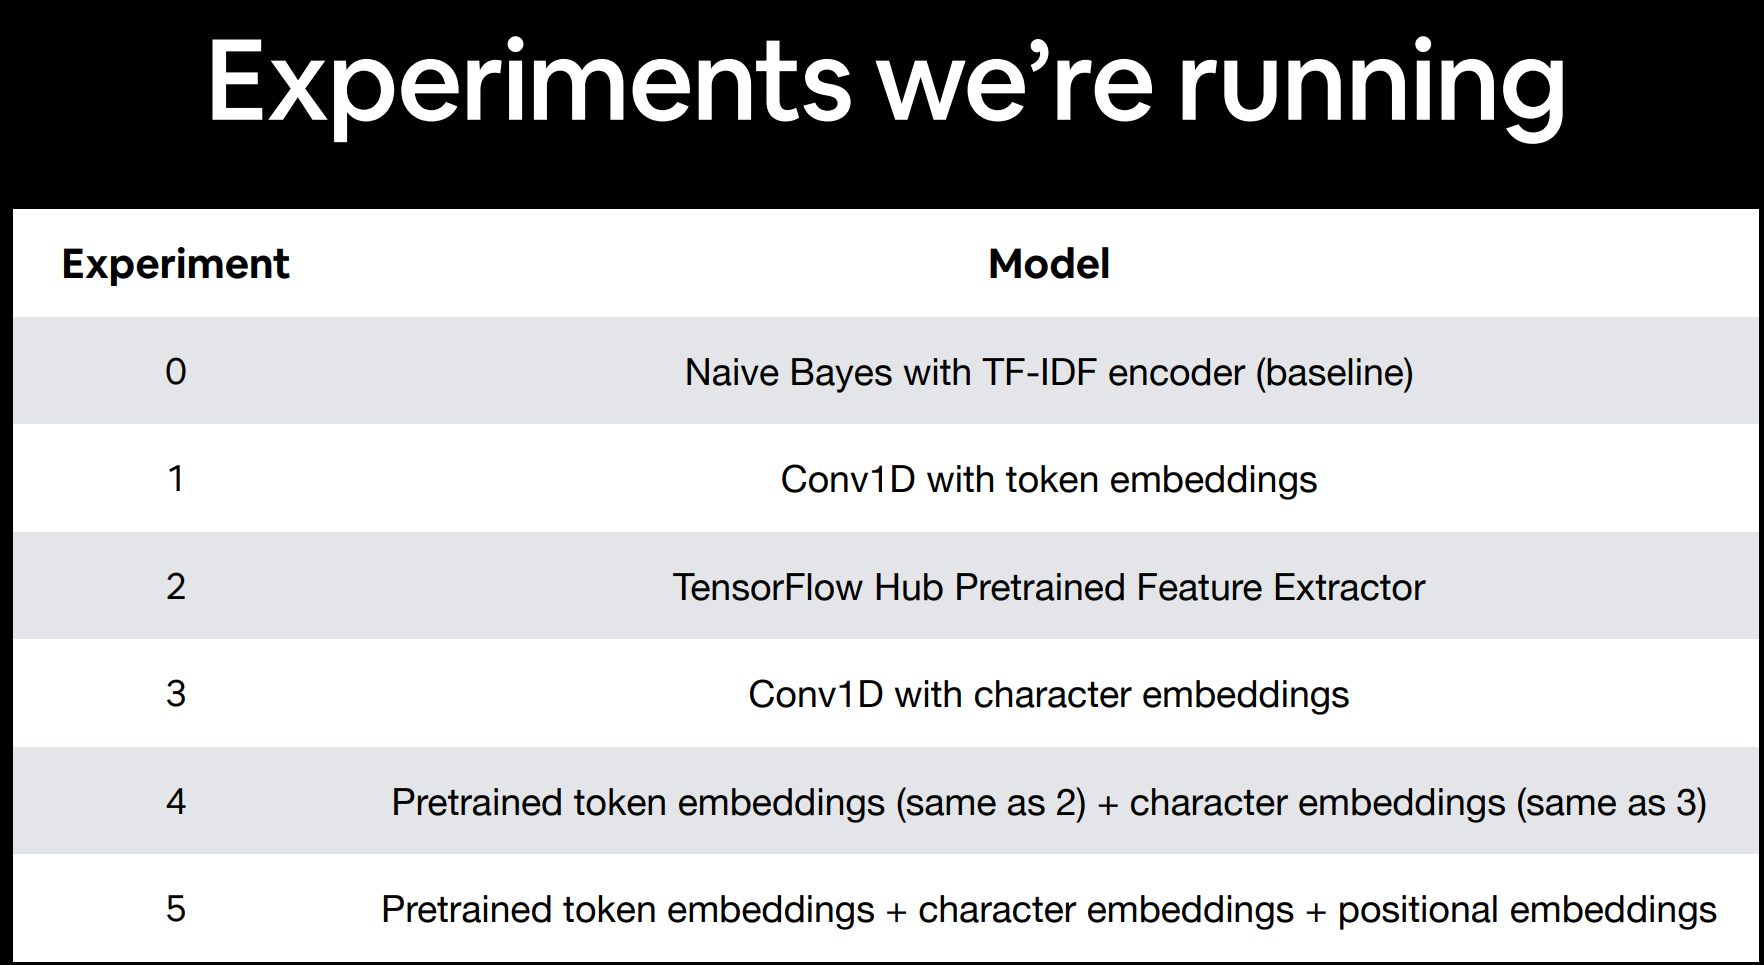

## BUILDING OUR BASELINE MODEL (model_0)
* The way to asses a model is by comparing the model accuracy with a **baseline model**
* The baseline model should be easy to perform,should be stable(better **not to take neural networks** which can give different results)


In [ ]:
## Model 0- TF-IDF Multinomial bayes classifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline

# Creating a pipeline
model_0=Pipeline([
    ("tf-idf",TfidfVectorizer()),
    ("multinomial_nb_classfier",MultinomialNB())
])

#Fitting the pipeline
model_0.fit(
    X=train_sentences,
    y=train_labels_encoded
)

Pipeline(steps=[('tf-idf', TfidfVectorizer()),
                ('multinomial_nb_classfier', MultinomialNB())])

In [ ]:
#Evaluating the  baseline model
model_0.score(X=validation_sentences,y=validation_labels_encoded)

0.7218323844829869

In [ ]:
# Getting confusion matrix for understanding deep
base_line_preds=model_0.predict(validation_sentences)

In [ ]:
!wget https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/refs/heads/main/extras/helper_functions.py

--2025-08-23 06:08:19--  https://raw.githubusercontent.com/mrdbourke/tensorflow-deep-learning/refs/heads/main/extras/helper_functions.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10246 (10K) [text/plain]
Saving to: ‘helper_functions.py’

helper_functions.py 100%[===================>]  10.01K  --.-KB/s    in 0s      

2025-08-23 06:08:19 (68.2 MB/s) - ‘helper_functions.py’ saved [10246/10246]



In [ ]:
from helper_functions  import calculate_results

In [ ]:
base_line_results=calculate_results(y_true=validation_labels_encoded,y_pred=base_line_preds)
base_line_results

{'accuracy': 72.1832384482987,
 'precision': 0.7186466952323352,
 'recall': 0.7218323844829869,
 'f1': 0.6989250353450294}

## Model 1(Conv 1D with token embeddings)

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers

In [ ]:
#Lets see how long are each sentences
sent_lens=[len(sentence.split()) for sentence in train_sentences]
avg_sent_len=np.mean(sent_lens)
print(avg_sent_len)

26.338269273494777


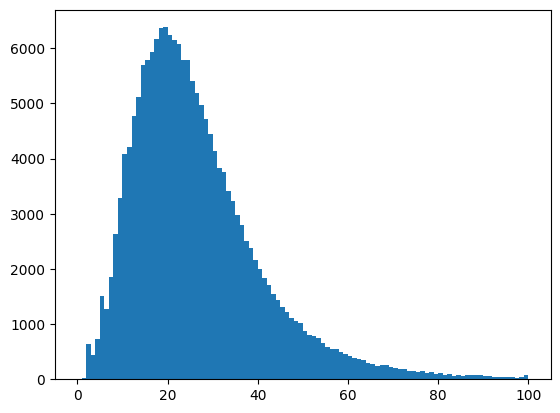

In [ ]:
import matplotlib.pyplot as plt
plt.hist(sent_lens,bins=100,range=[0,100]);

In [ ]:
# How long of sentences cover 95% of examples?
output_seq_len=np.percentile(sent_lens,95)
print(output_seq_len)

55.0


### Creating text Vectorization layer
The text vectorisation layer is a layer which maps from text to embeddings i.e.. it **tokenises the text into words assigning number from most occuring to least occuring**.

In [ ]:
# How many words in vocab is taken from the same paper above
max_vocab_length=68000

In [ ]:
from tensorflow.keras.layers import TextVectorization
text_vectorizer=TextVectorization(
    max_tokens=max_vocab_length,
    output_sequence_length=int(output_seq_len)
)

I0000 00:00:1755929302.508402      73 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1755929302.509056      73 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [ ]:
# Adapt text vectorizer to training sentences
text_vectorizer.adapt(train_sentences)

In [ ]:
# Test text vectorizer on random sentences
import random
target_sentence=random.choice(train_sentences)
print(f"Sample:\n{  target_sentence}")
print(f"length of sentence:\n{len(target_sentence.split())}")
print(f"\nVectorized:\n{text_vectorizer([target_sentence])}")

Sample:
to examine long-term longitudinal associations between changes in glycemic index and glycemic load with glycemic and metabolic control among latino adults with diabetes .
length of sentence:
24

Vectorized:
[[   6  534  335 1341  992   30  146    5 1431  203    3 1431 1323    7
  1431    3  671   35  116 5735  266    7  223    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0]]


In [ ]:
rct_20k_text_vocab=text_vectorizer.get_vocabulary()

In [ ]:
print(f"Number of words in vocab:{len(rct_20k_text_vocab)}")
print(f"Most common words:{rct_20k_text_vocab[:5]}")
print(f"Least common words:{rct_20k_text_vocab[-10:]}")

Number of words in vocab:64841
Most common words:['', '[UNK]', 'the', 'and', 'of']
Least common words:['aarm', 'aaqol', 'aaq', 'aanhui', 'aana', 'aainduced', 'aaigroup', 'aachener', 'aachen', 'aaacp']


In [ ]:
#Getting configuration of our text vectorizer
text_vectorizer.get_config()

{'name': 'text_vectorization',
 'trainable': True,
 'dtype': {'module': 'keras',
  'class_name': 'DTypePolicy',
  'config': {'name': 'float32'},
  'registered_name': None},
 'max_tokens': 68000,
 'standardize': 'lower_and_strip_punctuation',
 'split': 'whitespace',
 'ngrams': None,
 'output_mode': 'int',
 'output_sequence_length': 55,
 'pad_to_max_tokens': False,
 'sparse': False,
 'ragged': False,
 'vocabulary': None,
 'idf_weights': None,
 'encoding': 'utf-8',
 'vocabulary_size': 64841}

### Making word embeddings for our model
the text vectorizer has some information but the numbers are not at all related so embedding layer makes that connection for each word

In [ ]:
from tensorflow.keras.layers import Embedding
token_embedding_layer=Embedding(
    input_dim=len(rct_20k_text_vocab),
    output_dim=128,
    mask_zero=True,
    name="token_embedding_layer",

)

In [ ]:
print(f"Sentence berfore vectorisation:{target_sentence}")
vectorized_sentence=text_vectorizer([target_sentence])
print(f"Sentence after vectorisation:{vectorized_sentence}")
embedd_dentence=token_embedding_layer(vectorized_sentence)
print(f"Sentence after embedding:{embedd_dentence} shape:{embedd_dentence.shape}")

Sentence berfore vectorisation:to examine long-term longitudinal associations between changes in glycemic index and glycemic load with glycemic and metabolic control among latino adults with diabetes .
Sentence after vectorisation:[[   6  534  335 1341  992   30  146    5 1431  203    3 1431 1323    7
  1431    3  671   35  116 5735  266    7  223    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0]]
Sentence after embedding:[[[-0.03983896 -0.005256    0.01650206 ...  0.04526577  0.04219215
    0.02555222]
  [ 0.02539409  0.04665614  0.00928035 ... -0.0350836   0.03919004
   -0.03545433]
  [-0.03380144  0.00144207  0.03154706 ... -0.02547066 -0.01816382
    0.03588087]
  ...
  [-0.0157483  -0.01359677  0.03067729 ... -0.0454015  -0.03506887
    0.00637077]
  [-0.0157483  -0.01359677  0.03067729 ... -0.0454015  -0.03506887
    0.00637077]
  [-0.0157483  -0.01359677  0.03067729

### Improving the model data loading
* preprocessing large no of samples ineffeciently is as slow as possible results years so to improve data loading we use `tf.data`

In [ ]:
train_dataset=tf.data.Dataset.from_tensor_slices((train_sentences,train_labels_one_hot))
val_dataset=tf.data.Dataset.from_tensor_slices((validation_sentences,validation_labels_one_hot))
test_dataset=tf.data.Dataset.from_tensor_slices((test_sentences,test_labels_one_hot))

In [ ]:
# Tasking the dataset and turning them into prefetched dataset
train_dataset=train_dataset.batch(32).prefetch(tf.data.AUTOTUNE)
val_dataset=val_dataset.batch(32).prefetch(tf.data.AUTOTUNE)
test_dataset=test_dataset.batch(32).prefetch(tf.data.AUTOTUNE)

### Building `model_1` (Conv 1D with token embeddings)

In [ ]:
# Create  1D conv model to process input sequences
inputs=layers.Input(shape=(1,),dtype=tf.string)
text_vectors=text_vectorizer(inputs)
token_embeddings=token_embedding_layer(text_vectors)
x=layers.Conv1D(64,kernel_size=5,padding="same",activation="relu")(token_embeddings)
x=layers.GlobalAveragePooling1D()(x)
outputs=layers.Dense(num_classes,activation="softmax")(x)
model_1=tf.keras.Model(inputs,outputs,name="model_1_conv_1d")

# Compiling the model
model_1.compile(
    loss=tf.keras.losses.CategoricalCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(),
    metrics=["accuracy"]
)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:938: UserWarning: Layer 'conv1d' (of type Conv1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


In [ ]:
model_1.summary()

Model: "model_1_conv_1d"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 1)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ text_vectorization                   │ (None, 55)                  │               0 │
│ (TextVectorization)                  │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ token_embedding_layer (Embedding)    │ (None, 55, 128)             │       8,299,648 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d (Conv1D)                      │ (None, 55, 64)              │          41,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling1d             │ (None, 64)                  │               0 │
│ (GlobalAveragePooling1D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 5)                   │             325 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 8,340,997 (31.82 MB)

 Trainable params: 8,340,997 (31.82 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Fit the model
history_1=model_1.fit(
    train_dataset,
    steps_per_epoch=int(0.1*len(train_dataset)),
    epochs=3,
    validation_data=val_dataset,
    validation_steps=int(0.1*len(val_dataset))
)

Epoch 1/3


I0000 00:00:1755929309.934201     178 cuda_dnn.cc:529] Loaded cuDNN version 90300


562/562 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.5136 - loss: 1.1784 - val_accuracy: 0.7370 - val_loss: 0.6925
Epoch 2/3
562/562 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.7419 - loss: 0.6880 - val_accuracy: 0.7733 - val_loss: 0.6355
Epoch 3/3
562/562 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7665 - loss: 0.6274 - val_accuracy: 0.7829 - val_loss: 0.6041


In [ ]:
model_1.evaluate(val_dataset)

945/945 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7823 - loss: 0.6054


[0.6077585816383362, 0.7822719216346741]

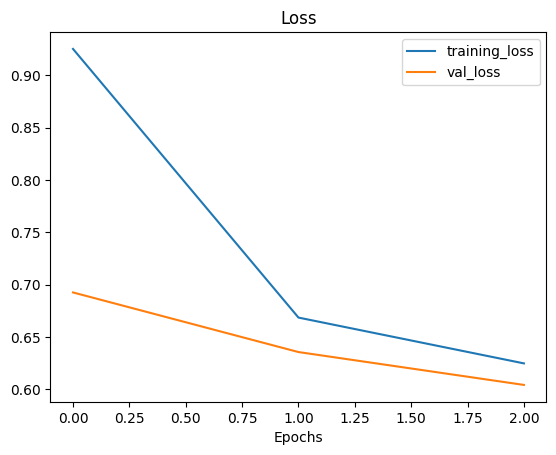

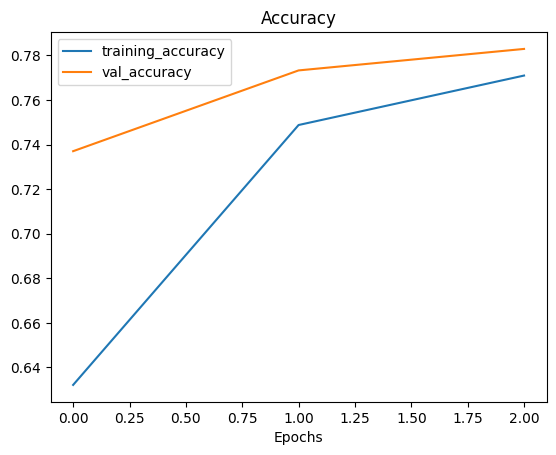

In [ ]:
from helper_functions import plot_loss_curves
plot_loss_curves(history_1)

In [ ]:
model_1_pred_probs=model_1.predict(val_dataset)
model_1_pred_probs,model_1_pred_probs.shape

945/945 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


(array([[4.19335932e-01, 1.34106144e-01, 1.34095684e-01, 2.56355762e-01,
         5.61064593e-02],
        [4.37245071e-01, 2.99049854e-01, 9.61415470e-03, 2.45843112e-01,
         8.24776199e-03],
        [1.83512524e-01, 1.34428237e-02, 2.34274799e-03, 8.00635099e-01,
         6.68348512e-05],
        ...,
        [4.68227654e-06, 5.92169119e-04, 5.79285086e-04, 1.41961129e-06,
         9.98822391e-01],
        [6.67965785e-02, 4.84593928e-01, 9.21843126e-02, 6.77261800e-02,
         2.88699090e-01],
        [1.48394927e-01, 6.37671471e-01, 4.33608852e-02, 5.64257428e-02,
         1.14147015e-01]], dtype=float32),
 (30212, 5))

In [ ]:
# Convert pred probs
model_1_preds=tf.argmax(model_1_pred_probs,axis=1)
model_1_preds,model_1_preds.shape

(<tf.Tensor: shape=(30212,), dtype=int64, numpy=array([0, 0, 3, ..., 4, 1, 1])>,
 TensorShape([30212]))

In [ ]:
# Calculate model_1 results
model_1_results=calculate_results(y_true=validation_labels_encoded,y_pred=model_1_preds)
model_1_results

{'accuracy': 78.22719449225474,
 'precision': 0.7791596822860704,
 'recall': 0.7822719449225474,
 'f1': 0.7800179173918376}

In [ ]:
base_line_results

{'accuracy': 72.1832384482987,
 'precision': 0.7186466952323352,
 'recall': 0.7218323844829869,
 'f1': 0.6989250353450294}

## Model 2 (Tensorflow pretrained feature extractor)

**🤔Why trying pretrain embeddings??**

* pretrained embeddings are trained of vast amount of data which makes the them learned the underlying features and shapes to be recognised
* Here are some reasons why they are better:
   * Capturing Rich Semantic Meaning
   * Drastically Improved Performance on Small Datasets(when there are small datasets it is very useful to use pretrained because with the small dataset cant have understood the natural language)
   * Better Generalization and Handling of Vocabulary

**Note:**<br>
1.While using pretrained are helpful here are the pointswhen not to use:
*  **Highly Specialized Domain**: If your text is from a very niche domain (e.g., legal contracts from the 18th century, specific molecular biology papers, or unique company jargon), the meaning of words might be very different from their general use. In this case, embeddings trained on your specific corpus might capture these specialized meanings better.


### What are we using??
Lets use pretrained embeddings **Universal sentence encoder** from tensorflow hub

In [ ]:
# This is the critical change: import from tf_keras instead of tensorflow.keras
# import tf_keras as keras
# from tf_keras import layers
# Make sure to run 'pip install tf-keras' first

In [ ]:


import tensorflow as tf
import tensorflow_hub as hub

from tensorflow import keras
from tensorflow.keras import layers

module_url="https://tfhub.dev/google/universal-sentence-encoder/4"

# This layer is now defined correctly for modern TensorFlow/Keras
tf_hub_embedding_layer=hub.KerasLayer(
    module_url,
    trainable=False,
    name="universal_sentence_encoder",

)


In [ ]:
random_train_sentence=random.choice(train_sentences)
print(f"random sentence is `{random_train_sentence}`")
use_embedded_sentence=tf_hub_embedding_layer([random_train_sentence])
print(f"embeddings after passing random sentence is (first 30 vectors):\n{use_embedded_sentence[0][:30]} \nshape: {use_embedded_sentence.shape}")

random sentence is `the overall survival with laparoscopic vs orc was @ % vs @ % , respectively ( p = @ ) .`
embeddings after passing random sentence is (first 30 vectors):
[-0.03058478 -0.08115444 -0.00447375 -0.03460623  0.06671486 -0.01472215
  0.03812063  0.02289988  0.0503272   0.0443456   0.08309041  0.06627833
  0.02791932  0.0782054  -0.0252811   0.00492189  0.01869911  0.00752123
  0.04595121  0.00987106  0.08807842  0.0430671  -0.01081625  0.00260144
  0.03488814  0.04479527  0.01522877  0.07910427 -0.06765353  0.02964799] 
shape: (1, 512)


### Building and compiling the model_2

In [ ]:
import tensorflow as tf
import tensorflow_hub as hub
from tensorflow.keras import layers
from tensorflow.keras import Model
from tensorflow import keras


# --- THIS IS THE NEW, CORRECT METHOD ---

# 1. Create a custom Keras Layer that wraps the TensorFlow Hub model
@keras.utils.register_keras_serializable()
class UniversalSentenceEncoderLayer(layers.Layer):
    def __init__(self, **kwargs):
        super(UniversalSentenceEncoderLayer, self).__init__(**kwargs)
        # Load the Hub model once during initialization
        self.hub_layer = hub.load("https://tfhub.dev/google/universal-sentence-encoder/4")

    def call(self, inputs):
        # Pass the inputs to the loaded Hub model
        return self.hub_layer(inputs)

# --- Now, build the model using our new custom layer ---

# Input layer remains the same
inputs = layers.Input(shape=[], dtype=tf.string, name="input_layer")

# Use our custom layer instead of hub.KerasLayer or Lambda
# This cleanly integrates the Hub model into the Keras model
pretrained_embedding = UniversalSentenceEncoderLayer(name="universal_sentence_encoder")(inputs)

# The rest of your model architecture is correct and remains unchanged
x = layers.Dense(128, activation="relu")(pretrained_embedding)
outputs = layers.Dense(num_classes, activation="softmax")(x)
model_2 = Model(inputs=inputs, outputs=outputs, name="model_2_use")

# Compile the model
model_2.compile(
    loss="categorical_crossentropy",
    optimizer=tf.keras.optimizers.Adam(),
    metrics=["accuracy"],
    jit_compile=False
)

# This will now build successfully
model_2.summary()

In [ ]:

# # Your model architecture remains the same
# inputs=layers.Input(shape=[],dtype=tf.string,name="input_layer")
# pretrained_embedding=tf_hub_embedding_layer(inputs)
# x=layers.Dense(128,activation="relu")(pretrained_embedding)
# outputs=layers.Dense(num_classes,activation="softmax")(x)
# model_2=keras.Model(inputs,outputs,name="model_2_universal_sentence_encoder")

# # Compiling the model
# model_2.compile(
#     loss=keras.losses.CategoricalCrossentropy(),
#     optimizer=keras.optimizers.Adam(),
#     metrics=["accuracy"])

# # Verify the model
# model_2.summary()



In [ ]:
model_2.fit(train_dataset,
            epochs=3,
            validation_data=val_dataset,
            steps_per_epoch=int(0.1*len(train_dataset)),
            validation_steps=int(0.1*len(val_dataset))

            )

Epoch 1/3
562/562 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - accuracy: 0.5896 - loss: 1.0966 - val_accuracy: 0.6888 - val_loss: 0.7948
Epoch 2/3
562/562 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.7050 - loss: 0.7707 - val_accuracy: 0.7035 - val_loss: 0.7524
Epoch 3/3
562/562 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.7170 - loss: 0.7530 - val_accuracy: 0.7141 - val_loss: 0.7375


In [ ]:
# Evaluating on total validation dataset
model_2.evaluate(val_dataset)

945/945 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.7150 - loss: 0.7381


[0.7394394874572754, 0.7146167159080505]

In [ ]:
model_2_pred_probs=model_2.predict(val_dataset)
model_2_pred_probs

945/945 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step


array([[0.415974  , 0.37371337, 0.00141152, 0.20266579, 0.00623539],
       [0.353949  , 0.48709223, 0.00284886, 0.15402636, 0.00208355],
       [0.23343612, 0.16578132, 0.01640579, 0.5449301 , 0.03944669],
       ...,
       [0.00172664, 0.00549533, 0.05282371, 0.00100076, 0.9389535 ],
       [0.00363003, 0.04827287, 0.19109121, 0.0013496 , 0.7556563 ],
       [0.19061728, 0.32123965, 0.42707112, 0.00537562, 0.05569629]],
      dtype=float32)

In [ ]:
model_2_preds=model_2_pred_probs.argmax(1)

In [ ]:
model_2_results=calculate_results(y_true=validation_labels_encoded,y_pred=model_2_preds)
model_2_results

{'accuracy': 71.46167085926122,
 'precision': 0.7151973793719503,
 'recall': 0.7146167085926122,
 'f1': 0.7116489103746267}

In [ ]:
base_line_results

{'accuracy': 72.1832384482987,
 'precision': 0.7186466952323352,
 'recall': 0.7218323844829869,
 'f1': 0.6989250353450294}

In [ ]:
model_1_results

{'accuracy': 78.22719449225474,
 'precision': 0.7791596822860704,
 'recall': 0.7822719449225474,
 'f1': 0.7800179173918376}

## Model 3 (Conv1D with character embeddings)
* The model disussed used a combination of token and character embeddings
* previously we have used token embeddings(basically word by word) but now use character(character by character)

### Creating character level tokenizer

In [ ]:
def split_chars(text):
    return " ".join(list(text))
split_chars(train_sentences[0])

't o   i n v e s t i g a t e   t h e   e f f i c a c y   o f   @   w e e k s   o f   d a i l y   l o w - d o s e   o r a l   p r e d n i s o l o n e   i n   i m p r o v i n g   p a i n   ,   m o b i l i t y   ,   a n d   s y s t e m i c   l o w - g r a d e   i n f l a m m a t i o n   i n   t h e   s h o r t   t e r m   a n d   w h e t h e r   t h e   e f f e c t   w o u l d   b e   s u s t a i n e d   a t   @   w e e k s   i n   o l d e r   a d u l t s   w i t h   m o d e r a t e   t o   s e v e r e   k n e e   o s t e o a r t h r i t i s   (   o a   )   .'

In [ ]:
train_chars=[split_chars(sentence) for sentence in train_sentences]
val_chars=[split_chars(sentence) for sentence in validation_sentences]
test_chars=[split_chars(sentence) for sentence in test_sentences]


In [ ]:
train_chars[0]

't o   i n v e s t i g a t e   t h e   e f f i c a c y   o f   @   w e e k s   o f   d a i l y   l o w - d o s e   o r a l   p r e d n i s o l o n e   i n   i m p r o v i n g   p a i n   ,   m o b i l i t y   ,   a n d   s y s t e m i c   l o w - g r a d e   i n f l a m m a t i o n   i n   t h e   s h o r t   t e r m   a n d   w h e t h e r   t h e   e f f e c t   w o u l d   b e   s u s t a i n e d   a t   @   w e e k s   i n   o l d e r   a d u l t s   w i t h   m o d e r a t e   t o   s e v e r e   k n e e   o s t e o a r t h r i t i s   (   o a   )   .'

In [ ]:
char_lens=[len(sentence) for sentence in train_sentences]
mean_char_len=np.mean(char_lens)
print(mean_char_len)


149.3662574983337


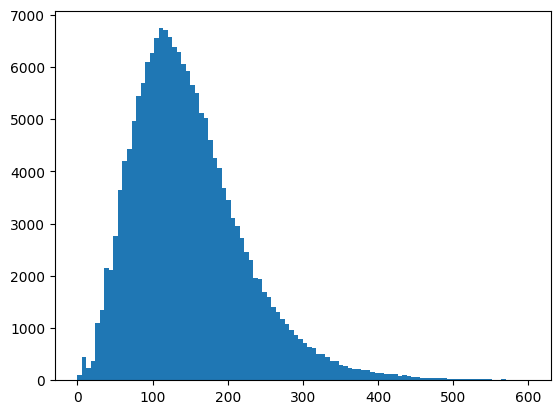

In [ ]:
 import matplotlib.pyplot as plt
 plt.hist(char_lens,bins=100,range=[0,600]);

In [ ]:
# finding the 95% percentile
output_seq_char_len=int(np.percentile(char_lens,95))
output_seq_char_len

290

In [ ]:
all_possible_chars=(set("  ".join(val_chars+train_chars+test_chars)))
# one is used for unknown (if came)
NUM_CHAR_TOKENS=len(all_possible_chars)+1
NUM_CHAR_TOKENS

58

In [ ]:
# training char level tokens
char_vectorizer=TextVectorization(
    max_tokens=NUM_CHAR_TOKENS,
    output_sequence_length=output_seq_char_len,
    standardize="lower_and_strip_punctuation",
    name="char_vectorizer"
)



In [ ]:
# Adapt char vectorizer
char_vectorizer.adapt(train_chars)

In [ ]:
char_vocab=char_vectorizer.get_vocabulary()
print(f"Number of different characters in vocab:{len(char_vocab)}")
print(f"Most common characters:{char_vocab[:10]}")
print(f"Least common characters:{char_vocab[-10:]}")

Number of different characters in vocab:28
Most common characters:['', '[UNK]', 'e', 't', 'i', 'a', 'n', 'o', 'r', 's']
Least common characters:['g', 'y', 'w', 'v', 'b', 'k', 'x', 'z', 'q', 'j']


In [ ]:
# Test out character vectorizer
random_train_chars = random.choice(train_chars)
print(f"Charified text:\n{random_train_chars}")
print(f"\nLength of chars: {len(random_train_chars.split())}")
vectorized_chars = char_vectorizer([random_train_chars])
print(f"\nVectorized chars:\n{vectorized_chars}")
print(f"\nLength of vectorized chars: {len(vectorized_chars[0])}")

Charified text:
t h e   r e c o v e r y   t i m e   t o   m o b i l i z a t i o n   ,   a m b u l a t i o n   ,   a n d   s p o n t a n e o u s   m i c t u r i t i o n   w e r e   m e a s u r e d   .

Length of chars: 79

Vectorized chars:
[[ 3 13  2  8  2 11  7 21  2  8 19  3  4 15  2  3  7 15  7 22  4 12  4 25
   5  3  4  7  6  5 15 22 16 12  5  3  4  7  6  5  6 10  9 14  7  6  3  5
   6  2  7 16  9 15  4 11  3 16  8  4  3  4  7  6 20  2  8  2 15  2  5  9
  16  8  2 10  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
   0  0  0  0  0  0 

### Creating character level embeddings for our model


In [ ]:
char_embeddings_layer=tf.keras.layers.Embedding(
    input_dim=len(char_vocab),
    output_dim=25,#This 25 is taken from paper we are building https://arxiv.org/pdf/1612.05251
    mask_zero=False,
    name="character_embedding_layer"
)


In [ ]:
print(f"Charified text:\n{random_train_chars}")
char_embed_example=char_embeddings_layer(char_vectorizer([random_train_chars]))
print(f"Embeddings of random sentence is \n\n{char_embed_example}\n")
print(f"Shape of character mebeddings is {char_embed_example.shape}")

Charified text:
t h e   r e c o v e r y   t i m e   t o   m o b i l i z a t i o n   ,   a m b u l a t i o n   ,   a n d   s p o n t a n e o u s   m i c t u r i t i o n   w e r e   m e a s u r e d   .
Embeddings of random sentence is 

[[[ 0.01834712 -0.01000329  0.02524883 ... -0.04621886 -0.02476031
   -0.0304807 ]
  [-0.04567116  0.03986282  0.00496237 ... -0.00086943  0.0254623
   -0.00817608]
  [ 0.01230385 -0.02178758  0.02675003 ...  0.04858068  0.03967377
    0.02945775]
  ...
  [-0.00227844  0.04546588  0.0359074  ... -0.03438931  0.0202994
   -0.00617161]
  [-0.00227844  0.04546588  0.0359074  ... -0.03438931  0.0202994
   -0.00617161]
  [-0.00227844  0.04546588  0.0359074  ... -0.03438931  0.0202994
   -0.00617161]]]

Shape of character mebeddings is (1, 290, 25)


### Building and training the model_3

In [ ]:
# Build the model using keras.Model
inputs=tf.keras.layers.Input(shape=(1,),dtype=tf.string)
char_vectors=char_vectorizer(inputs)
char_embeddings=char_embeddings_layer(char_vectors)
x=tf.keras.layers.Conv1D(filters=64,kernel_size=5,padding="same",activation="relu")(char_embeddings)
# x=layers.GlobalAveragePooling1D()(x)
x=tf.keras.layers.GlobalMaxPooling1D()(x)
print(x.shape)
# x=tf.keras.layers.Flatten()(x)
outputs=tf.keras.layers.Dense(num_classes,activation="softmax")(x)
model_3=tf.keras.Model(inputs,outputs,name="conv1D_char_embeddings")

# Compile the model
model_3.compile(
    loss=tf.keras.losses.CategoricalCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(),
    metrics=["accuracy"]
)

# View the summary of model
model_3.summary()

(None, 64)


Model: "conv1D_char_embeddings"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 1)                   │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ char_vectorizer (TextVectorization)  │ (None, 290)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ character_embedding_layer            │ (None, 290, 25)             │             700 │
│ (Embedding)                          │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 290, 64)             │           8,064 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_max_pooling1d                 │ (None, 64)                  │               0 │
│ (GlobalMaxPooling1D)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 5)                   │             325 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 9,089 (35.50 KB)

 Trainable params: 9,089 (35.50 KB)

 Non-trainable params: 0 (0.00 B)

### Optimimizing the train_chars fortraining

In [ ]:
train_char_dataset=tf.data.Dataset.from_tensor_slices((train_chars,train_labels_one_hot)).batch(32).prefetch(tf.data.AUTOTUNE)
val_char_dataset=tf.data.Dataset.from_tensor_slices((val_chars,validation_labels_one_hot)).batch(32).prefetch(tf.data.AUTOTUNE)
test_char_dataset=tf.data.Dataset.from_tensor_slices((test_chars,test_labels_one_hot)).batch(32).prefetch(tf.data.AUTOTUNE)

In [ ]:
train_char_dataset

<_PrefetchDataset element_spec=(TensorSpec(shape=(None,), dtype=tf.string, name=None), TensorSpec(shape=(None, 5), dtype=tf.float64, name=None))>

In [ ]:
model_3_history=model_3.fit(
    train_char_dataset,
    steps_per_epoch=int(0.1*len(train_char_dataset)),
    epochs=8,
    validation_data=val_char_dataset,
    validation_steps=int(0.1*len(val_char_dataset))
)

Epoch 1/8
562/562 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.4189 - loss: 1.4092 - val_accuracy: 0.5808 - val_loss: 1.0595
Epoch 2/8
562/562 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.5848 - loss: 1.0462 - val_accuracy: 0.6187 - val_loss: 0.9474
Epoch 3/8
562/562 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6246 - loss: 0.9492 - val_accuracy: 0.6596 - val_loss: 0.8771
Epoch 4/8
562/562 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6501 - loss: 0.8971 - val_accuracy: 0.6636 - val_loss: 0.8436
Epoch 5/8
562/562 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6675 - loss: 0.8603 - val_accuracy: 0.6749 - val_loss: 0.8245
Epoch 6/8
562/562 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6729 - loss: 0.8467 - val_accuracy: 0.6918 - val_loss: 0.7967
Epoch 7/8
562/562 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6807 - loss: 0.8195 - val_accuracy: 0.6915 - val_loss: 0.7954
Epoch 8/8
562/562 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6870 - loss: 0.8036 - val_accuracy: 0.6965 - v

### Evaluation of model_3

In [ ]:
model_3_pred_probs=model_3.predict(val_char_dataset)
model_3.evaluate(val_char_dataset)

945/945 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
945/945 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6900 - loss: 0.8033


[0.8060198426246643, 0.6897590160369873]

In [ ]:
model_3_preds=model_3_pred_probs.argmax(1)
model_3_preds

array([1, 1, 3, ..., 4, 4, 1])

In [ ]:
model_3_results=calculate_results(
    y_true=validation_labels_encoded,
    y_pred=model_3_preds
    )

In [ ]:
model_3_results

{'accuracy': 68.97590361445783,
 'precision': 0.7012662675288187,
 'recall': 0.6897590361445783,
 'f1': 0.6833116641877742}

In [ ]:
base_line_results

{'accuracy': 72.1832384482987,
 'precision': 0.7186466952323352,
 'recall': 0.7218323844829869,
 'f1': 0.6989250353450294}

## Model 4 Combining the Character embeddings and Sentence Embeddings (hybrid model)

1.Creating token level embedding

2.Creating character level embedding

3.Combining the models using the `layers.concatenate`

4.build a series of layers according to the [paper](https://arxiv.org/pdf/1612.05251)


### Building and compiling Our model

In [ ]:
from tensorflow.keras import layers
import tensorflow as tf
import tensorflow_hub as hub



# Initialising the token input model
token_inputs=tf.keras.layers.Input(shape=[],dtype=tf.string,name="token_input")
token_embeddings=UniversalSentenceEncoderLayer(name="universal_sentence_encoder")(token_inputs)
token_outputs=tf.keras.layers.Dense(128,activation="relu")(token_embeddings)
token_model=tf.keras.Model(token_inputs,token_outputs,name="token_model")

# Initialising char input model
char_inputs=tf.keras.layers.Input(shape=(1,),dtype=tf.string,name="char_input")
char_vectors=char_vectorizer(char_inputs) # Assuming char_vectorizer is defined elsewhere
char_embeddings=char_embeddings_layer(char_vectors) # Assuming char_embeddings_layer is defined elsewhere
char_bi_lstm=tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(24))(char_embeddings) # Bi LSTM  model used in the paper
char_model=tf.keras.Model(char_inputs,char_bi_lstm,name="char_model")

# print(token_model.summary())
# print(char_model.summary())
# Concatenate the model
token_char_concat = layers.Concatenate(name="token_char_hybrid")([token_model.output,
                                                                  char_model.output])

# Create output layers
combined_dropout = tf.keras.layers.Dropout(0.5)(token_char_concat)
combined_dense= tf.keras.layers.Dense(128,activation="relu")(combined_dropout)
final_dropout=tf.keras.layers.Dropout(0.5)(combined_dense)
final_output=tf.keras.layers.Dense(num_classes,activation="softmax")(final_dropout) # Assuming num_classes is defined elsewhere


model_4=tf.keras.Model([token_model.input,char_model.input],final_output,name="model_4")

# Compile the model
model_4.compile(
    loss=tf.keras.losses.CategoricalCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(),
    metrics=["accuracy"],
    jit_compile=False
)

# Verify the model summary
model_4.summary()

Model: "model_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ char_input (InputLayer)   │ (None, 1)              │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ token_input (InputLayer)  │ (None)                 │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ char_vectorizer           │ (None, 290)            │              0 │ char_input[0][0]       │
│ (TextVectorization)       │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ universal_sentence_encod… │ (None, 512)            │              0 │ token_input[0][0]      │
│ (UniversalSentenceEncode… │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ character_embedding_layer │ (None, 290, 25)        │            700 │ char_vectorizer[1][0]  │
│ (Embedding)               │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_4 (Dense)           │ (None, 128)            │         65,664 │ universal_sentence_en… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bidirectional             │ (None, 48)             │          9,600 │ character_embedding_l… │
│ (Bidirectional)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ token_char_hybrid         │ (None, 176)            │              0 │ dense_4[0][0],         │
│ (Concatenate)             │                        │                │ bidirectional[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout (Dropout)         │ (None, 176)            │              0 │ token_char_hybrid[0][… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_5 (Dense)           │ (None, 128)            │         22,656 │ dropout[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_1 (Dropout)       │ (None, 128)            │              0 │ dense_5[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_6 (Dense)           │ (None, 5)              │            645 │ dropout_1[0][0]        │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 99,265 (387.75 KB)

 Trainable params: 99,265 (387.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:

# tf.keras.utils.plot_model(model_4,show_shapes=True)

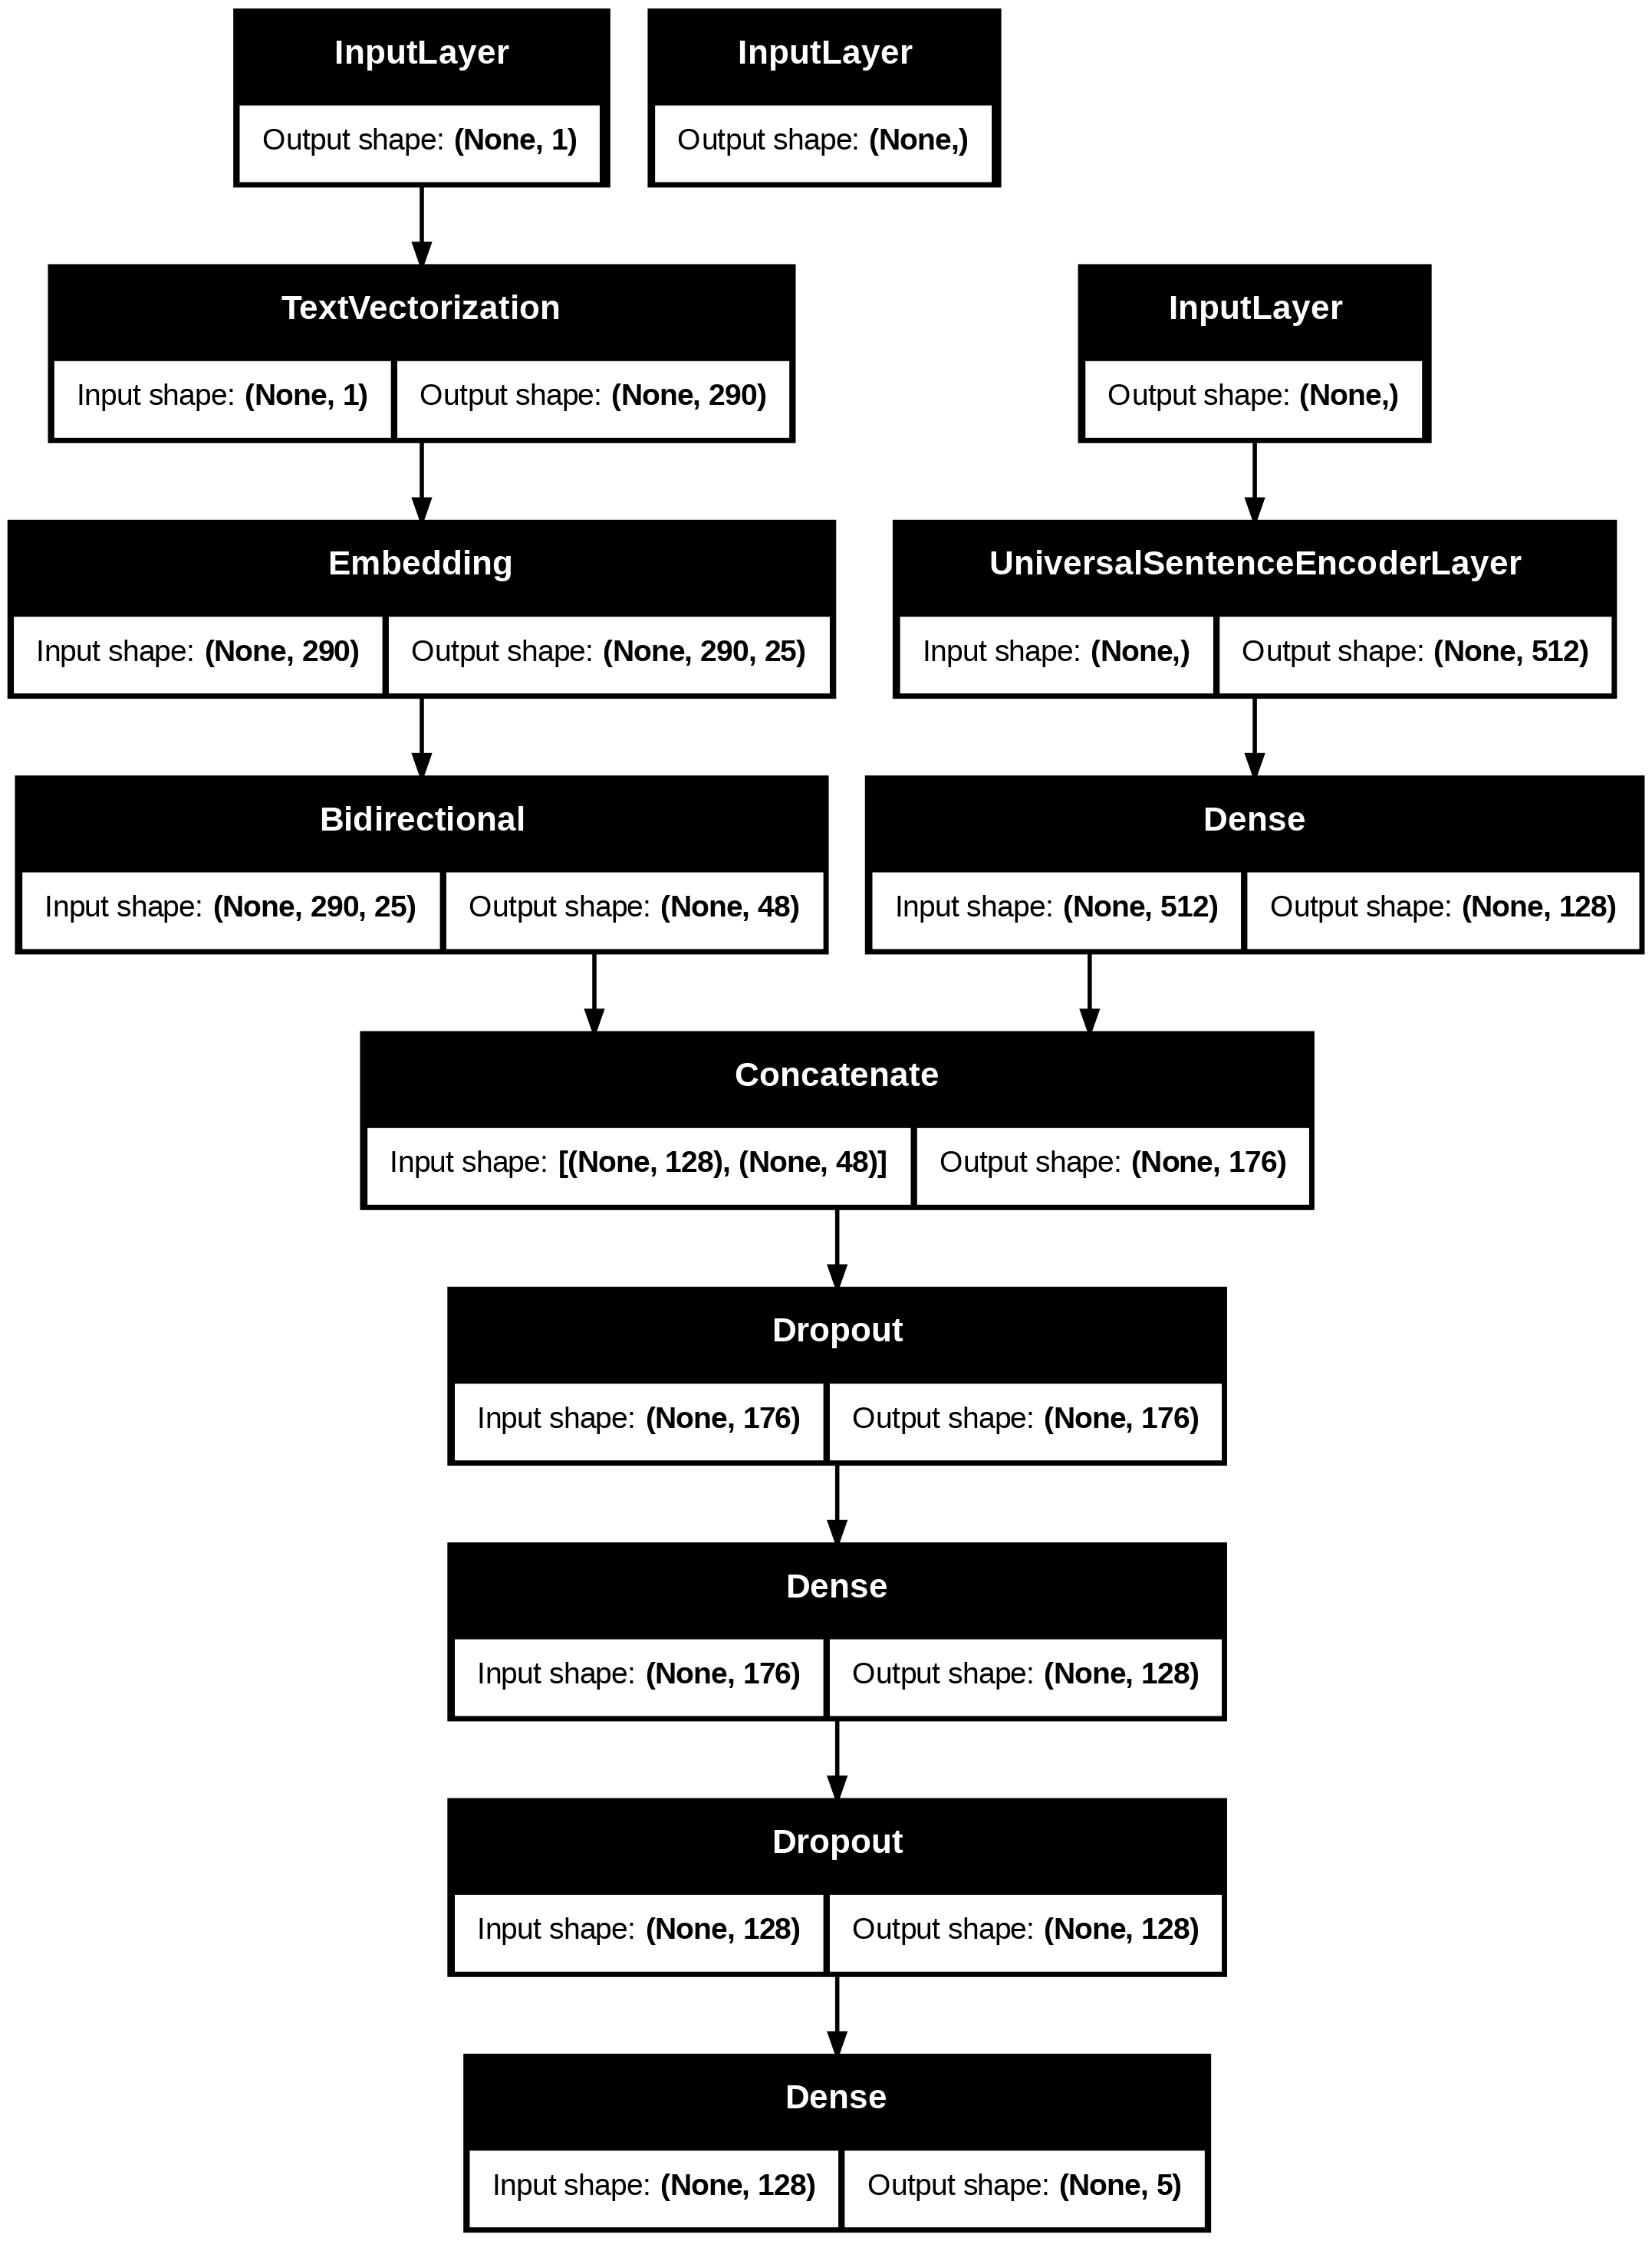

### Prefetching the data so that the training becomes faster

In [ ]:
# Combine chars and tokens into dataset
train_token_char_data=tf.data.Dataset.from_tensor_slices((train_sentences,train_chars)) # Make data
train_token_char_labels=tf.data.Dataset.from_tensor_slices(train_labels_one_hot) # Make labels
train_token_char_dataset=tf.data.Dataset.zip((train_token_char_data,train_token_char_labels)) # Combining Data
# Prefetch and batch train data
train_token_char_dataset=train_token_char_dataset.batch(32).prefetch(tf.data.AUTOTUNE)

In [ ]:
## Repeat the process for validation

# Combine chars and tokens into dataset
val_token_char_data=tf.data.Dataset.from_tensor_slices((validation_sentences,val_chars)) # Make data
val_token_char_labels=tf.data.Dataset.from_tensor_slices(validation_labels_one_hot) # Make labels
val_token_char_dataset=tf.data.Dataset.zip((val_token_char_data,val_token_char_labels)) # Combining Data
# Prefetch and batch train data
val_token_char_dataset=val_token_char_dataset.batch(32).prefetch(tf.data.AUTOTUNE)

In [ ]:
train_token_char_dataset,val_token_char_dataset

(<_PrefetchDataset element_spec=((TensorSpec(shape=(None,), dtype=tf.string, name=None), TensorSpec(shape=(None,), dtype=tf.string, name=None)), TensorSpec(shape=(None, 5), dtype=tf.float64, name=None))>,
 <_PrefetchDataset element_spec=((TensorSpec(shape=(None,), dtype=tf.string, name=None), TensorSpec(shape=(None,), dtype=tf.string, name=None)), TensorSpec(shape=(None, 5), dtype=tf.float64, name=None))>)

### Fitting the model 4!

In [ ]:
history_4=model_4.fit(
    train_token_char_dataset,
    steps_per_epoch=int(0.1*len(train_token_char_dataset)),
    epochs=5,
    validation_data=val_token_char_dataset,
    validation_steps=int(0.1*len(val_token_char_dataset))
)

Epoch 1/5
562/562 ━━━━━━━━━━━━━━━━━━━━ 24s 28ms/step - accuracy: 0.5194 - loss: 1.1694 - val_accuracy: 0.6925 - val_loss: 0.7938
Epoch 2/5
562/562 ━━━━━━━━━━━━━━━━━━━━ 14s 25ms/step - accuracy: 0.6858 - loss: 0.8141 - val_accuracy: 0.7241 - val_loss: 0.7265
Epoch 3/5
562/562 ━━━━━━━━━━━━━━━━━━━━ 14s 25ms/step - accuracy: 0.7032 - loss: 0.7798 - val_accuracy: 0.7330 - val_loss: 0.6987
Epoch 4/5
562/562 ━━━━━━━━━━━━━━━━━━━━ 14s 25ms/step - accuracy: 0.7148 - loss: 0.7487 - val_accuracy: 0.7517 - val_loss: 0.6716
Epoch 5/5
562/562 ━━━━━━━━━━━━━━━━━━━━ 14s 25ms/step - accuracy: 0.7200 - loss: 0.7453 - val_accuracy: 0.7463 - val_loss: 0.6592


In [ ]:
# Evaluation on dataset
model_4_pred_probs=model_4.predict(val_token_char_dataset)
model_4_preds=tf.argmax(model_4_pred_probs,axis=1)

945/945 ━━━━━━━━━━━━━━━━━━━━ 13s 12ms/step


In [ ]:
model_4_preds

<tf.Tensor: shape=(30212,), dtype=int64, numpy=array([0, 0, 3, ..., 4, 4, 1])>

In [ ]:
model_4_results=calculate_results(y_true=validation_labels_encoded,y_pred=model_4_preds)
model_4_results

{'accuracy': 74.46709916589434,
 'precision': 0.7422897160551849,
 'recall': 0.7446709916589435,
 'f1': 0.7389289997979447}

In [ ]:
# Best model results
model_1_results

{'accuracy': 78.22719449225474,
 'precision': 0.7791596822860704,
 'recall': 0.7822719449225474,
 'f1': 0.7800179173918376}

In [ ]:
# Baseline results
base_line_results

{'accuracy': 72.1832384482987,
 'precision': 0.7186466952323352,
 'recall': 0.7218323844829869,
 'f1': 0.6989250353450294}

### Model 4 Summary
* The combination is of course has crossed baseline and performed well but **it does not capable of beating the best model

## Model 5 Pretrained token embeddings + char embeddings + **Positional Embeddings**

**🧐What can we do better**:

* We know that the real world dataset also comes with order i.e... *Conclusion doesn't come before the Background

* So we encode this into the model in someway that it can help while predicting with greater accuracy

* The way we are going to encode is using positional encodings

> **Note : The features we are developing need to be available at the deployement !**

In [ ]:
train_df.head()

,target,text,line_number,total lines
0,OBJECTIVE,to investigate the efficacy of @ weeks of dail...,0,11
1,METHODS,a total of @ patients with primary knee oa wer...,1,11
2,METHODS,outcome measures included pain reduction and i...,2,11
3,METHODS,pain was assessed using the visual analog pain...,3,11
4,METHODS,secondary outcome measures included the wester...,4,11


In [ ]:
np.unique(train_df["total lines"])

array([ 3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19,
       20, 21, 22, 23, 24, 25, 26, 27, 28, 30])

### Creating Positional embeddings


In [ ]:
# Using tensorflow one hot encoding for encoding line numbers
train_line_numbers_one_hot=tf.one_hot(train_df["line_number"].to_numpy(),depth=15)
train_line_numbers_one_hot[:15],train_df['line_number'][:15]

(<tf.Tensor: shape=(15, 15), dtype=float32, numpy=
 array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0.

In [ ]:
# Using tensorflow one hot encoding for encoding line numbers
val_line_numbers_one_hot=tf.one_hot(validation_df["line_number"].to_numpy(),depth=15)
val_line_numbers_one_hot[:15],validation_df['line_number'][:15]

(<tf.Tensor: shape=(15, 15), dtype=float32, numpy=
 array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 1., 0., 0., 0., 0.

In [ ]:
# Using tensorflow one hot encoding for encoding line numbers
test_line_numbers_one_hot=tf.one_hot(test_df["line_number"].to_numpy(),depth=15)
test_line_numbers_one_hot[:15],test_df['line_number'][:15]

(<tf.Tensor: shape=(15, 15), dtype=float32, numpy=
 array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 1., 0., 0., 0.

In [ ]:
# np.unique((train_df['line_number']*5)//train_df['total lines'])

In [ ]:
# Encoding total no of features
train_df['total lines'].value_counts()

total lines
11    24468
10    23639
12    22113
9     19400
13    18438
14    14610
8     12285
15    10768
7      7464
16     7429
17     5202
6      3353
18     3344
19     2480
20     1281
5      1146
21      770
22      759
23      264
4       215
24      200
25      182
26       81
28       58
3        32
30       31
27       28
Name: count, dtype: int64

<Axes: >

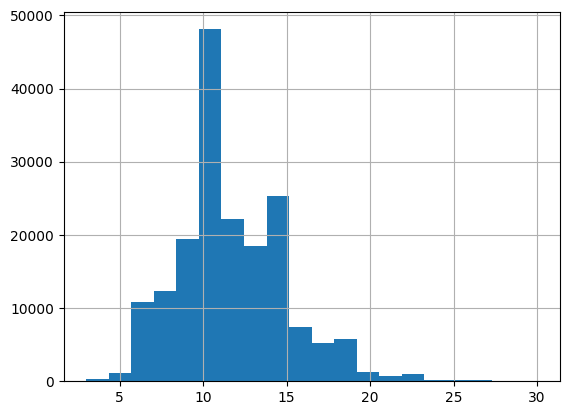

In [ ]:
train_df['total lines'].hist(bins=20)

In [ ]:
# Create one hot encoding for the line numbers
train_total_lines_one_hot=tf.one_hot(train_df['total lines'].to_numpy(),depth=20)
test_total_lines_one_hot=tf.one_hot(test_df['total lines'].to_numpy(),depth=20)
val_total_lines_one_hot=tf.one_hot(validation_df['total lines'].to_numpy(),depth=20)
train_total_lines_one_hot[:15],train_df['total lines'][:15]

(<tf.Tensor: shape=(15, 20), dtype=float32, numpy=
 array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.,
         0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0

### Building and compiling  the model 5

In [ ]:
# from tensorflow.keras import layers
# import tensorflow as tf
# import tensorflow_hub as hub



# # Initialising the token input model
# token_inputs=tf.keras.layers.Input(shape=[],dtype=tf.string,name="token_input")
# token_embeddings=UniversalSentenceEncoderLayer(name="universal_sentence_encoder")(token_inputs)
# token_outputs=tf.keras.layers.Dense(128,activation="relu")(token_embeddings)
# token_model=tf.keras.Model(token_inputs,token_outputs,name="token_model")

# # Initialising char input model
# char_inputs=tf.keras.layers.Input(shape=(1,),dtype=tf.string,name="char_input")
# char_vectors=char_vectorizer(char_inputs) # Assuming char_vectorizer is defined elsewhere
# char_embeddings=char_embeddings_layer(char_vectors) # Assuming char_embeddings_layer is defined elsewhere
# char_bi_lstm=tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(24))(char_embeddings) # Bi LSTM  model used in the paper
# char_model=tf.keras.Model(char_inputs,char_bi_lstm,name="char_model")

# # Building the positional encodings of the data
# line_numbers_input=tf.keras.Input(shape=(15,),name="line_numbers_input")
# total_lines_input=tf.keras.Input(shape=(20,),name="total_lines_input")
# line_features=tf.keras.layers.Concatenate(name="line_feat_concat")([line_numbers_input,
#                                             total_lines_input,
#                                             ])
# total_lines_outputs=layers.Dense(10,activation="sigmoid",name="line_feat_densr")(line_features)



# # Concatenate the model
# token_char_lines_concat = layers.Concatenate(name="token_char_hybrid")([token_model.output,
#                                                                   char_model.output,
#                                                                   total_lines_outputs,
#                                                                   ])

# # Create output layers
# combined_dropout = tf.keras.layers.Dropout(0.5)(token_char_lines_concat)
# combined_dense= tf.keras.layers.Dense(128,activation="relu")(combined_dropout)
# final_dropout=tf.keras.layers.Dropout(0.5)(combined_dense)
# final_output=tf.keras.layers.Dense(num_classes,activation="softmax")(final_dropout) # Assuming num_classes is defined elsewhere


# model_5=tf.keras.Model([token_model.input,char_model.input],final_output,name="model_4")

# # Compile the model
# model_5.compile(
#     loss=tf.keras.losses.CategoricalCrossentropy(),
#     optimizer=tf.keras.optimizers.Adam(),
#     metrics=["accuracy"],
#     jit_compile=False
# )

# # Verify the model summary
# model_5.summary()

In [ ]:
# tf.keras.utils.plot_model(model_5,show_shapes=True)

### Building a tribrid embedding model

1.Create a token level model

2.Create a char level model

3.Create a model for  line numbers

4.Create a model for total lines
    
5.Concat the 1 and 2  using `tf.keras.layers.concatenate`

6.Concat the 3 , 4 and 5 using `tf.keras.layers.concatenate`

7.Create output layer and tribrid embeddings

In [ ]:
# Token inputs
token_inputs=tf.keras.layers.Input(shape=[],dtype=tf.string,name="token_input")
token_embeddings=UniversalSentenceEncoderLayer(name="token_embeddings")(token_inputs)
token_outputs=tf.keras.layers.Dense(128,activation="relu")(token_embeddings)
token_model=tf.keras.Model(token_inputs,token_outputs,name="token_model")

#Char inputs
char_inputs=tf.keras.layers.Input(shape=(1,),dtype=tf.string,name="char_input")
char_vectors=char_vectorizer(char_inputs)
char_embeddings=char_embeddings_layer(char_vectors)
char_bi_lstm=tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(24),name="char_lstm")(char_embeddings)
char_model=tf.keras.Model(char_inputs,char_bi_lstm,name="char_model")

# line numbers input
line_numbers_input=tf.keras.layers.Input(shape=(15,),dtype=tf.float32,name="line_numbers_input")
line_number_output=tf.keras.layers.Dense(32,activation="relu",name="line_number_dense")(line_numbers_input)
line_numbers_model=tf.keras.Model(line_numbers_input,line_number_output,name="line_number_model")

# total lines input
total_lines_input=tf.keras.layers.Input(shape=(20,),dtype=tf.float32,name="total_line_input")
total_line_output=tf.keras.layers.Dense(32,activation="relu",name="total_line_dense")(total_lines_input)
total_lines_model=tf.keras.Model(total_lines_input,total_line_output,name="total_line_model")

# Combining the token and char
token_char_embeddings=tf.keras.layers.Concatenate(name="token_char_concat")([token_model.output,
                                                                             char_model.output])

z=layers.Dense(256,activation="relu")(token_char_embeddings)
z=layers.Dropout(0.5,)(z)

# Combining the token_char with line numbers and total lines
tribrid_embeddings=tf.keras.layers.Concatenate(name="tribrid_concat")(
    [
        line_numbers_model.output,
        total_lines_model.output,
        z
    ]
)

# Create output layer of tribrid embeddings
output_layer=layers.Dense(5,activation="sigmoid",name="output_layer")(tribrid_embeddings)

# Put all the inputs and outputs together
model_5=tf.keras.Model(
    inputs=[
        line_numbers_model.input,
        total_lines_model.input,
        token_model.input,
        char_model.input
    ],
    outputs=output_layer
)




In [ ]:
model_5.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ char_input (InputLayer)   │ (None, 1)              │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ token_input (InputLayer)  │ (None)                 │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ char_vectorizer           │ (None, 290)            │              0 │ char_input[0][0]       │
│ (TextVectorization)       │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ token_embeddings          │ (None, 512)            │              0 │ token_input[0][0]      │
│ (UniversalSentenceEncode… │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ character_embedding_layer │ (None, 290, 25)        │            700 │ char_vectorizer[5][0]  │
│ (Embedding)               │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_12 (Dense)          │ (None, 128)            │         65,664 │ token_embeddings[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ char_lstm (Bidirectional) │ (None, 48)             │          9,600 │ character_embedding_l… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ token_char_concat         │ (None, 176)            │              0 │ dense_12[0][0],        │
│ (Concatenate)             │                        │                │ char_lstm[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ line_numbers_input        │ (None, 15)             │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ total_line_input          │ (None, 20)             │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_13 (Dense)          │ (None, 256)            │         45,312 │ token_char_concat[0][… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ line_number_dense (Dense) │ (None, 32)             │            512 │ line_numbers_input[0]… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ total_line_dense (Dense)  │ (None, 32)             │            672 │ total_line_input[0][0] │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_3 (Dropout)       │ (None, 256)            │              0 │ dense_13[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ tribrid_concat            │ (None, 320)            │              0 │ line_number_dense[0][… │
│ (Concatenate)             │                        │                │ total_line_dense[0][0… │
│                           │                        │                │ dropout_3[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ output_layer (Dense) 

 Total params: 124,065 (484.63 KB)

 Trainable params: 124,065 (484.63 KB)

 Non-trainable params: 0 (0.00 B)

### Visualize the model

In [ ]:
# tf.keras.utils.plot_model(model_5,show_shapes=True)

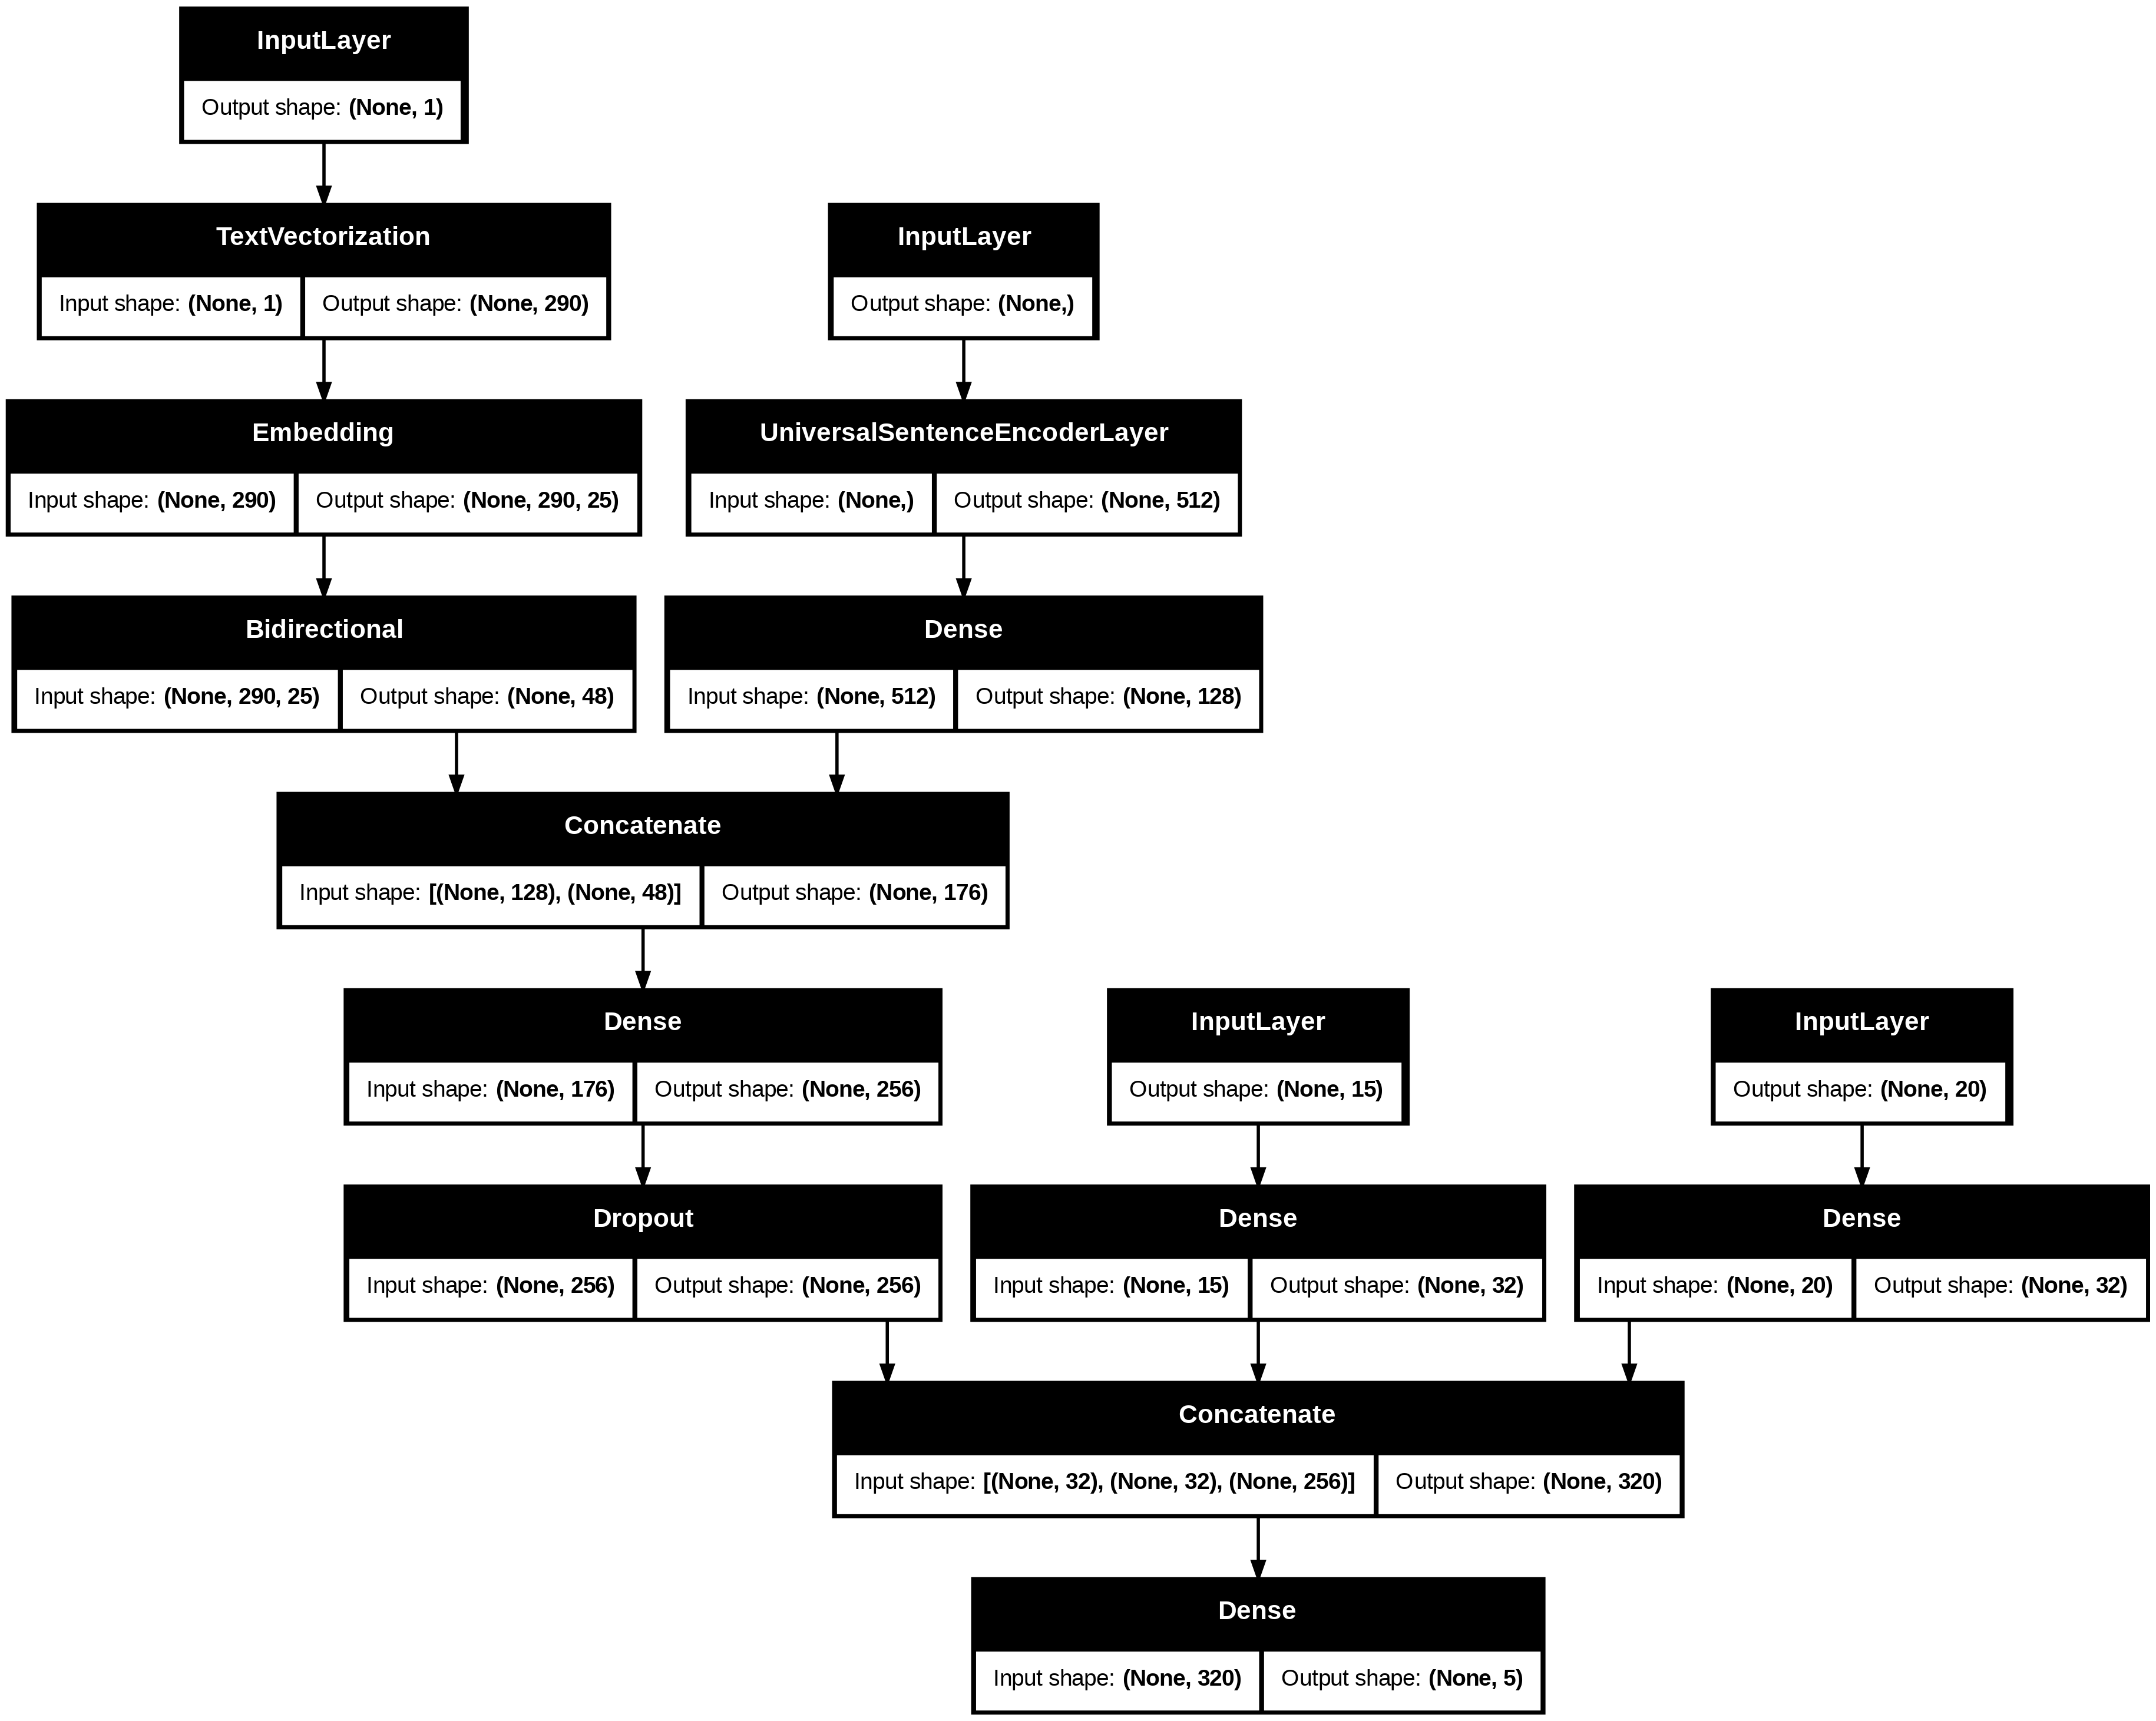

**What really is label smoothing 🤔?**
For categorical cross entropy the y_true looks like `[1,0,0,0]` when we use label(example 0.2) smoothing they will become `[0.85,0.05,0.05,0.05]` that is the true label has changed to $y=1-\alpha+\alpha/k$ where k is number of classes and false label has value $y=α/k$ .

So categorical cross entropy becomes $y*log(\hat{y})$


In [ ]:
# Compile the model
model_5.compile(loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.2),
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["accuracy"])


### Prefetching the data for making performance better

In [ ]:
# Combine the line_numbers,total_lines,chars,tokens
train_tribrid_data=tf.data.Dataset.from_tensor_slices((train_line_numbers_one_hot,train_total_lines_one_hot,train_sentences,train_chars))
train_tribrid_labels=tf.data.Dataset.from_tensor_slices(train_labels_one_hot)
train_tribrid_dataset=tf.data.Dataset.zip((train_tribrid_data,train_tribrid_labels))
# Prefetch and batch train data
train_tribrid_dataset=train_tribrid_dataset.batch(32).prefetch(tf.data.AUTOTUNE)

In [ ]:
# Combine the line_numbers,total_lines,chars,tokens
val_tribrid_data=tf.data.Dataset.from_tensor_slices((val_line_numbers_one_hot,val_total_lines_one_hot,validation_sentences,val_chars))
val_tribrid_labels=tf.data.Dataset.from_tensor_slices(validation_labels_one_hot)
val_tribrid_dataset=tf.data.Dataset.zip((val_tribrid_data,val_tribrid_labels))
# Prefetch and batch train data
val_tribrid_dataset=val_tribrid_dataset.batch(32).prefetch(tf.data.AUTOTUNE)

In [ ]:
# repeat for test dataset
test_tribrid_data=tf.data.Dataset.from_tensor_slices((test_line_numbers_one_hot,test_total_lines_one_hot,test_sentences,test_chars))
test_tribrid_labels=tf.data.Dataset.from_tensor_slices(test_labels_one_hot)
test_tribrid_dataset=tf.data.Dataset.zip((test_tribrid_data,test_tribrid_labels))
# Prefetch and batch train data
test_tribrid_dataset=test_tribrid_dataset.batch(32).prefetch(tf.data.AUTOTUNE)

### Fitting the Paper Model 🤯🤯!!!

In [ ]:
history_5=model_5.fit(
    train_tribrid_dataset,
    epochs=5,
    steps_per_epoch=int(0.1*len(train_tribrid_dataset)),
    validation_data=val_tribrid_dataset,
    validation_steps=int(0.1*len(val_tribrid_dataset))
)

Epoch 1/5
562/562 ━━━━━━━━━━━━━━━━━━━━ 25s 28ms/step - accuracy: 0.6324 - loss: 1.2219 - val_accuracy: 0.8002 - val_loss: 0.9839
Epoch 2/5
562/562 ━━━━━━━━━━━━━━━━━━━━ 15s 26ms/step - accuracy: 0.8153 - loss: 0.9715 - val_accuracy: 0.8278 - val_loss: 0.9499
Epoch 3/5
562/562 ━━━━━━━━━━━━━━━━━━━━ 15s 26ms/step - accuracy: 0.8158 - loss: 0.9567 - val_accuracy: 0.8291 - val_loss: 0.9401
Epoch 4/5
562/562 ━━━━━━━━━━━━━━━━━━━━ 15s 26ms/step - accuracy: 0.8353 - loss: 0.9395 - val_accuracy: 0.8334 - val_loss: 0.9297
Epoch 5/5
562/562 ━━━━━━━━━━━━━━━━━━━━ 15s 26ms/step - accuracy: 0.8365 - loss: 0.9325 - val_accuracy: 0.8394 - val_loss: 0.9246


In [ ]:
# Make the predictions with the model
model_5_pred_probs=model_5.predict(val_tribrid_dataset,verbose=1)
model_5_pred_probs

945/945 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step


array([[0.81692195, 0.357743  , 0.10609121, 0.68080425, 0.1679817 ],
       [0.80843323, 0.34666818, 0.29327622, 0.5461584 , 0.06909812],
       [0.5853592 , 0.3294589 , 0.35630727, 0.61548495, 0.19537082],
       ...,
       [0.25260827, 0.42179066, 0.27221245, 0.22187938, 0.8919421 ],
       [0.15322986, 0.6778723 , 0.37800327, 0.12865517, 0.7862007 ],
       [0.38664463, 0.81343764, 0.3495767 , 0.11704877, 0.28625485]],
      dtype=float32)

In [ ]:
model_5_preds=tf.argmax(model_5_pred_probs,axis=1)
model_5_preds

<tf.Tensor: shape=(30212,), dtype=int64, numpy=array([0, 0, 3, ..., 4, 4, 1])>

In [ ]:
# Calculate the results
model_5_results=calculate_results(y_true=validation_labels_encoded,y_pred=model_5_preds)
model_5_results

{'accuracy': 84.02621474910632,
 'precision': 0.8438135197791357,
 'recall': 0.8402621474910632,
 'f1': 0.8363135865062823}

In [ ]:
base_line_results

{'accuracy': 72.1832384482987,
 'precision': 0.7186466952323352,
 'recall': 0.7218323844829869,
 'f1': 0.6989250353450294}

In [ ]:
model_4_results

{'accuracy': 74.46709916589434,
 'precision': 0.7422897160551849,
 'recall': 0.7446709916589435,
 'f1': 0.7389289997979447}

In [ ]:
model_1_results

{'accuracy': 78.22719449225474,
 'precision': 0.7791596822860704,
 'recall': 0.7822719449225474,
 'f1': 0.7800179173918376}

### 😅😅 Finally we got the best results with that much of code for defining the model

## Plotting the results

In [ ]:
results=pd.DataFrame(
    (base_line_results,
    model_1_results,
    model_2_results,
    model_3_results,
    model_4_results,
    model_5_results),
    index=["0_naive_bayes_model","1_conv_model_token","2_feature_extractor_conv","3_conv_model_char","4_model_token_char_combined","5_model_token_char_pos_combined"]
)

<Axes: >

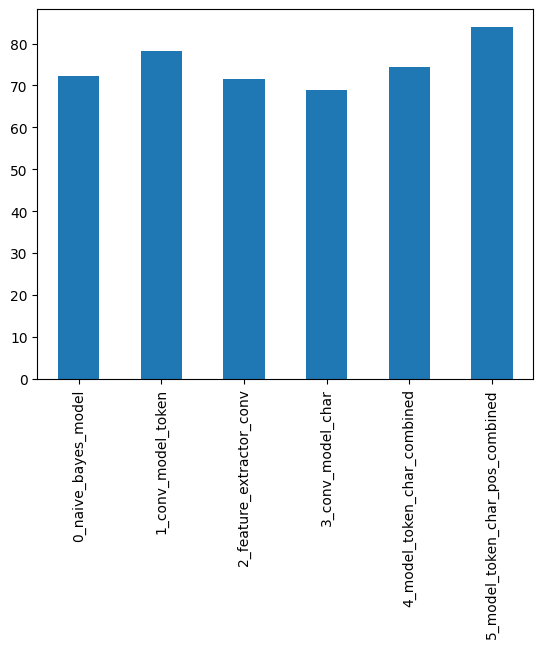

In [ ]:
results["accuracy"].plot.bar()

In [ ]:
results.accuracy=results.accuracy/100

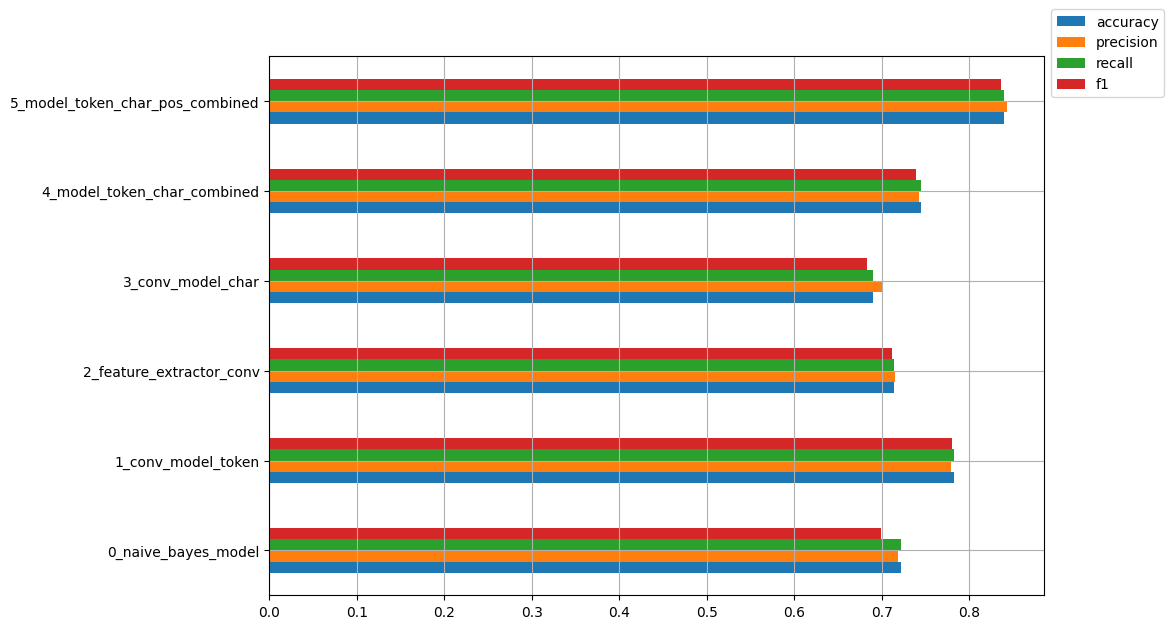

In [ ]:
# Plotting different metrics
results.plot(kind="barh",figsize=(10,7),).legend(bbox_to_anchor=(1,1.1))
plt.grid(True)

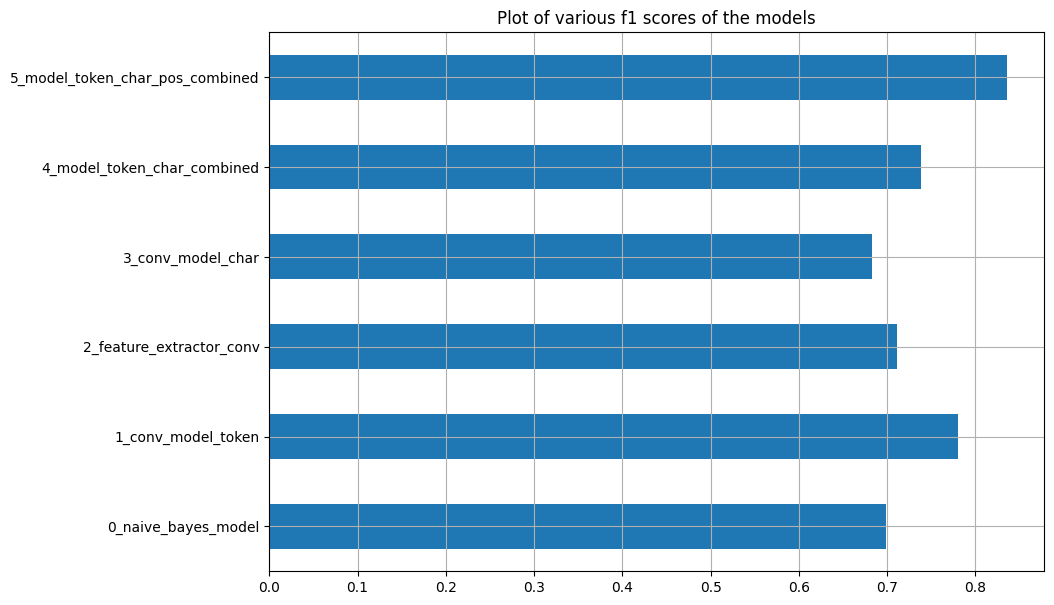

In [ ]:
# Plotting different metrics
results["f1"].plot(kind="barh",figsize=(10,7),)
plt.title("Plot of various f1 scores of the models")
plt.grid(True)

Text(0.5, 1.0, 'Plot of various f1 scores of the models')

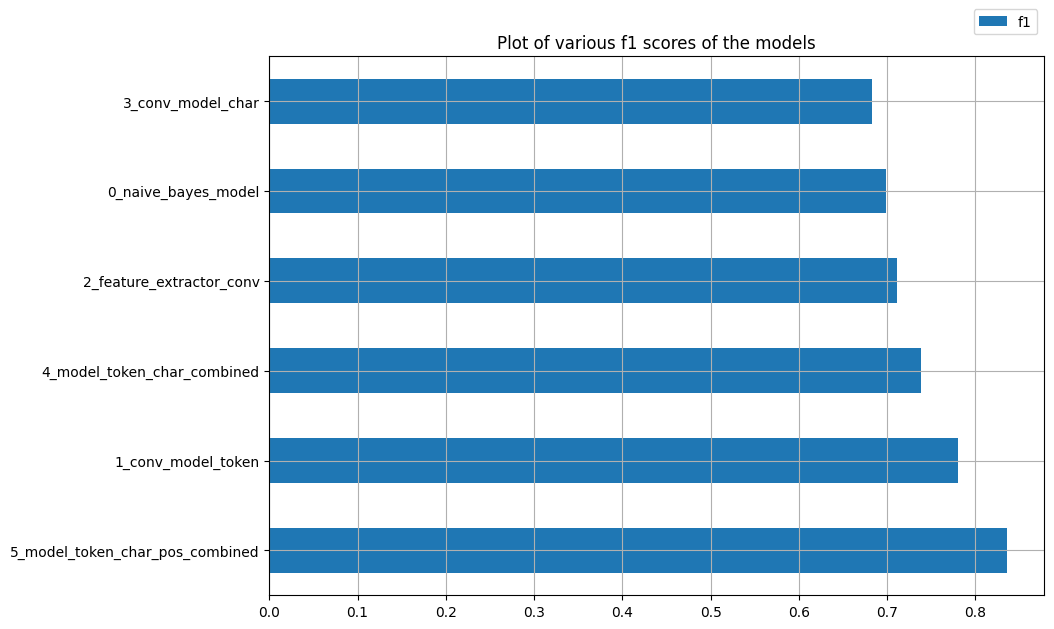

In [ ]:
results.sort_values("f1",ascending=False)["f1"].plot(kind="barh",figsize=(10,7)).legend(bbox_to_anchor=(1,1.1))
plt.grid(True)
plt.title("Plot of various f1 scores of the models")

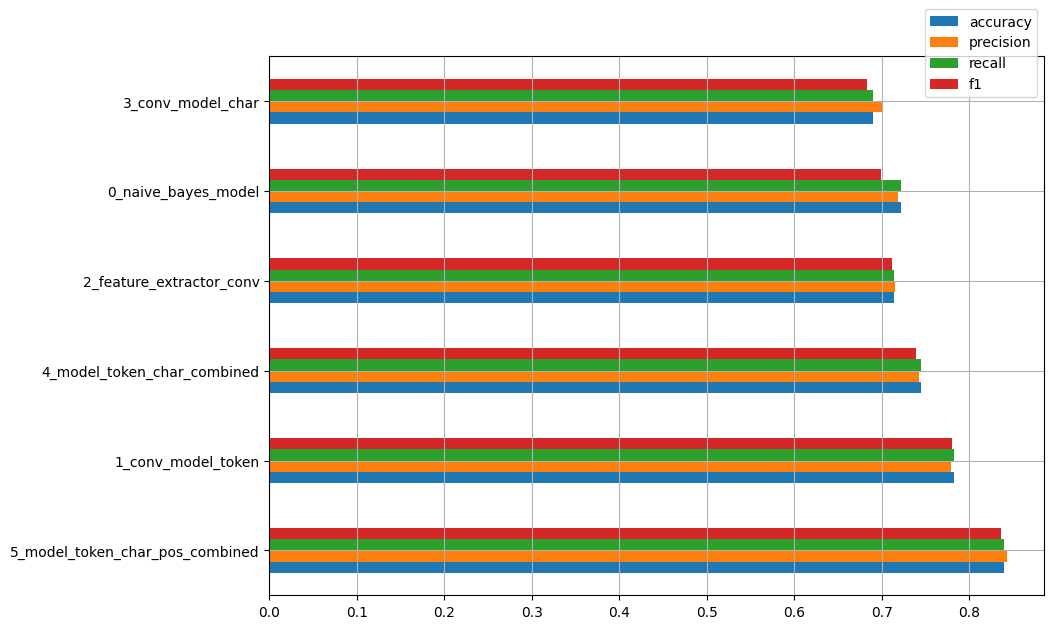

In [ ]:
results.sort_values("f1",ascending=False).plot(kind="barh",figsize=(10,7)).legend(bbox_to_anchor=(1,1.1))
plt.grid(True)


## Saving and loading the model

In [ ]:
# Save the best model to savedModel format
model_5.save("skimlit_tribrid.keras")

In [ ]:
model_loaded=tf.keras.models.load_model("skimlit_tribrid.keras")

In [ ]:
loaded_labels=tf.argmax(model_loaded.predict(val_tribrid_dataset),axis=1)

945/945 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step


In [ ]:
calculate_results(y_true=validation_labels_encoded,y_pred=loaded_labels)

{'accuracy': 84.02621474910632,
 'precision': 0.8438135197791357,
 'recall': 0.8402621474910632,
 'f1': 0.8363135865062823}

In [ ]:
model_5_results

{'accuracy': 84.02621474910632,
 'precision': 0.8438135197791357,
 'recall': 0.8402621474910632,
 'f1': 0.8363135865062823}